In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import os
from tqdm import tqdm
import h5py
from collections import Counter
from scipy import signal
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

# Set the custom color palette
CUSTOM_COLORS = {
    'primary': '#81308c',
    'secondary': '#003371',
    'dark': '#0d0d0d',
    'light': '#f2f2f2',
    'background': '#F8F4F8'
}

# Set global plot style
plt.rcParams['figure.facecolor'] = CUSTOM_COLORS['background']
plt.rcParams['axes.facecolor'] = CUSTOM_COLORS['background']
plt.rcParams['axes.edgecolor'] = CUSTOM_COLORS['dark']
plt.rcParams['axes.labelcolor'] = CUSTOM_COLORS['dark']
plt.rcParams['text.color'] = CUSTOM_COLORS['dark']
plt.rcParams['xtick.color'] = CUSTOM_COLORS['dark']
plt.rcParams['ytick.color'] = CUSTOM_COLORS['dark']
plt.rcParams['grid.color'] = '#CCCCCC'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Phoneme mapping (from your code)
LOGIT_TO_PHONEME = [
    'BLANK', 'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'B', 'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G', 'HH', 'IH', 'IY', 'JH', 'K', 'L', 'M',
    'N', 'NG', 'OW', 'OY', 'P', 'R', 'S', 'SH', 'T', 'TH', 'UH', 'UW',
    'V', 'W', 'Y', 'Z', 'ZH', ' | '
]

import h5py

def load_h5py_file(file_path):
    data = {
        'neural_features': [],
        'n_time_steps': [],
        'seq_class_ids': [],
        'seq_len': [],
        'transcriptions': [],
        'sentence_label': [],
        'session': [],
        'block_num': [],
        'trial_num': [],
    }
    # Open the hdf5 file for that day
    with h5py.File(file_path, 'r') as f:

        keys = list(f.keys())

        # For each trial in the selected trials in that day
        for key in keys:
            g = f[key]

            neural_features = g['input_features'][:]
            n_time_steps = g.attrs['n_time_steps']
            seq_class_ids = g['seq_class_ids'][:] if 'seq_class_ids' in g else None
            seq_len = g.attrs['seq_len'] if 'seq_len' in g.attrs else None
            transcription = g['transcription'][:] if 'transcription' in g else None
            sentence_label = g.attrs['sentence_label'][:] if 'sentence_label' in g.attrs else None
            session = g.attrs['session']
            block_num = g.attrs['block_num']
            trial_num = g.attrs['trial_num']

            data['neural_features'].append(neural_features)
            data['n_time_steps'].append(n_time_steps)
            data['seq_class_ids'].append(seq_class_ids)
            data['seq_len'].append(seq_len)
            data['transcriptions'].append(transcription)
            data['sentence_label'].append(sentence_label)
            data['session'].append(session)
            data['block_num'].append(block_num)
            data['trial_num'].append(trial_num)
    return data

import os

data = []
data_path = 'data/t15_copyTask_neuralData/hdf5_data_final'

sessions = os.listdir(data_path)
sessions.sort()
for session in tqdm(sessions):
    # Skip session when no test, train, val
    data.append([])

    session_files = os.listdir(os.path.join(data_path, session))
    session_files.sort()
    for file in session_files:
        file_path = os.path.join(data_path, session, file)
        data[-1].append(load_h5py_file(file_path))
    # print(f"Loaded session {session}")

# First, let's create a function to extract all data into a structured format
def extract_data_from_structure(data):
    """
    Extract data from your existing data structure into a DataFrame
    data[session_idx][split_idx] where split_idx: 0=test, 1=train, 2=val
    """
    all_trials = []
    
    for session_idx, session_data in enumerate(tqdm(data, desc="Processing sessions")):
        for split_idx, split_data in enumerate(session_data):
            # Determine split type
            if split_idx == 0:
                split_type = 'test'
            elif split_idx == 1:
                split_type = 'train'
            elif split_idx == 2:
                split_type = 'validation'
            else:
                split_type = 'unknown'
            
            # Get number of trials in this split
            n_trials = len(split_data['neural_features'])
            
            for trial_idx in range(n_trials):
                trial_info = {
                    'session_idx': session_idx,
                    'split': split_type,
                    'block_num': split_data['block_num'][trial_idx],
                    'trial_num': split_data['trial_num'][trial_idx],
                    'n_time_steps': split_data['n_time_steps'][trial_idx],
                    'sentence_label': split_data['sentence_label'][trial_idx],
                    'neural_features_shape': split_data['neural_features'][trial_idx].shape,
                    'seq_len': split_data['seq_len'][trial_idx] if split_data['seq_len'] is not None else None,
                }
                
                # Extract neural features stats
                neural_features = split_data['neural_features'][trial_idx]
                trial_info['neural_mean'] = np.mean(neural_features)
                trial_info['neural_std'] = np.std(neural_features)
                trial_info['neural_max'] = np.max(neural_features)
                trial_info['neural_min'] = np.min(neural_features)
                
                # Extract transcription if available
                if (split_data['transcriptions'] is not None and 
                    split_data['transcriptions'][trial_idx] is not None):
                    try:
                        transcription = split_data['transcriptions'][trial_idx]
                        trial_info['transcription'] = ''.join([chr(c) for c in transcription])
                        trial_info['word_count'] = len(trial_info['transcription'].split())
                    except:
                        trial_info['transcription'] = ''
                        trial_info['word_count'] = 0
                else:
                    trial_info['transcription'] = ''
                    trial_info['word_count'] = 0
                
                # Extract phoneme sequence if available
                if (split_data['seq_class_ids'] is not None and 
                    split_data['seq_class_ids'][trial_idx] is not None):
                    seq_class_ids = split_data['seq_class_ids'][trial_idx]
                                    
                    # Count actual phonemes (not padding)
                    actual_phonemes = []
                    for idx in seq_class_ids:
                        if idx < len(LOGIT_TO_PHONEME):
                            phoneme = LOGIT_TO_PHONEME[idx]
                            # Skip BLANK tokens (index 0) and ' | ' tokens if they're padding
                            if idx != 0 and phoneme != ' | ':
                                actual_phonemes.append(phoneme)
                    
                    trial_info['phoneme_sequence'] = actual_phonemes
                    trial_info['phoneme_count'] = len(actual_phonemes)
                    trial_info['unique_phonemes'] = len(set(actual_phonemes))
                else:
                    trial_info['phoneme_sequence'] = []
                    trial_info['phoneme_count'] = 0
                    trial_info['unique_phonemes'] = 0
                all_trials.append(trial_info)
    
    return pd.DataFrame(all_trials)

# First, let me check if your data is loaded
print(f"Number of sessions in data: {len(data)}")
if len(data) > 0:
    print(f"First session has {len(data[0])} splits: test, train, val")
    if len(data[0]) > 1:
        print(f"Train split in first session has {len(data[0][1]['neural_features'])} trials")
else:
    print("Data structure is empty. Please ensure data is loaded correctly.")

# Now extract data into DataFrame
df = extract_data_from_structure(data)
# After creating df, fix phoneme_count
print("\nChecking phoneme count data...")
print(f"Trials with seq_len: {df['seq_len'].notna().sum()}")
print(f"Trials with phoneme_sequence: {df['phoneme_sequence'].apply(lambda x: len(x) if x else 0).sum()}")

# If seq_len is mostly None or wrong, use actual phoneme sequence length
if df['seq_len'].isna().sum() > len(df) * 0.5:  # If more than 50% are NaN
    print("Using actual phoneme sequence length instead of seq_len")
    df['phoneme_count'] = df['phoneme_sequence'].apply(lambda x: len(x) if x else 0)
else:
    print(f"Using seq_len for phoneme count (mean: {df['seq_len'].mean():.1f})")
print(f"\nExtracted {len(df)} trials into DataFrame")
print(f"Columns: {df.columns.tolist()}")


100%|██████████| 45/45 [01:39<00:00,  2.21s/it]


Number of sessions in data: 45
First session has 1 splits: test, train, val


Processing sessions: 100%|██████████| 45/45 [01:56<00:00,  2.59s/it]



Checking phoneme count data...
Trials with seq_len: 9498
Trials with phoneme_sequence: 195546
Using seq_len for phoneme count (mean: 26.9)

Extracted 10948 trials into DataFrame
Columns: ['session_idx', 'split', 'block_num', 'trial_num', 'n_time_steps', 'sentence_label', 'neural_features_shape', 'seq_len', 'neural_mean', 'neural_std', 'neural_max', 'neural_min', 'transcription', 'word_count', 'phoneme_sequence', 'phoneme_count', 'unique_phonemes']



PART 1: TEMPORAL DISTRIBUTION


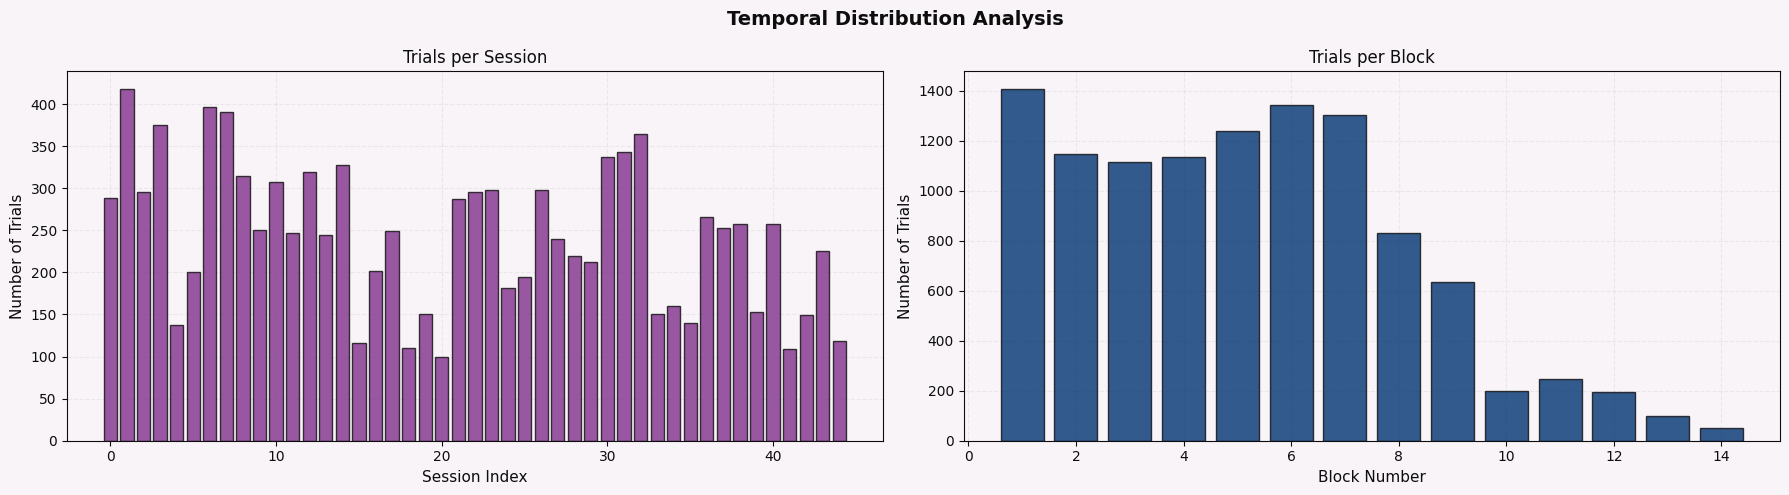

In [2]:

# ============================================================================
# PART 1: TEMPORAL DISTRIBUTION (Plots 1, 2, 3)
# ============================================================================

print("\n" + "="*60)
print("PART 1: TEMPORAL DISTRIBUTION")
print("="*60)

fig1, axes1 = plt.subplots(1, 2, figsize=(18, 5))
fig1.suptitle('Temporal Distribution Analysis', fontsize=14, fontweight='bold', color=CUSTOM_COLORS['dark'])

# Plot 1: Trials per session
session_trials = df.groupby('session_idx').size()
axes1[0].bar(session_trials.index, session_trials.values, 
             color=CUSTOM_COLORS['primary'], alpha=0.8, edgecolor=CUSTOM_COLORS['dark'])
axes1[0].set_xlabel('Session Index')
axes1[0].set_ylabel('Number of Trials')
axes1[0].set_title('Trials per Session')
axes1[0].grid(True, alpha=0.3, linestyle='--')
axes1[0].set_axisbelow(True)

# Plot 2: Trials per block
block_counts = df.groupby('block_num').size()
axes1[1].bar(block_counts.index, block_counts.values, 
             color=CUSTOM_COLORS['secondary'], alpha=0.8, edgecolor=CUSTOM_COLORS['dark'])
axes1[1].set_xlabel('Block Number')
axes1[1].set_ylabel('Number of Trials')
axes1[1].set_title('Trials per Block')
axes1[1].grid(True, alpha=0.3, linestyle='--')
axes1[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('./results/V2_temporal_distribution.png', dpi=300, bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
plt.show()



PART 2: DATA SPLIT ANALYSIS


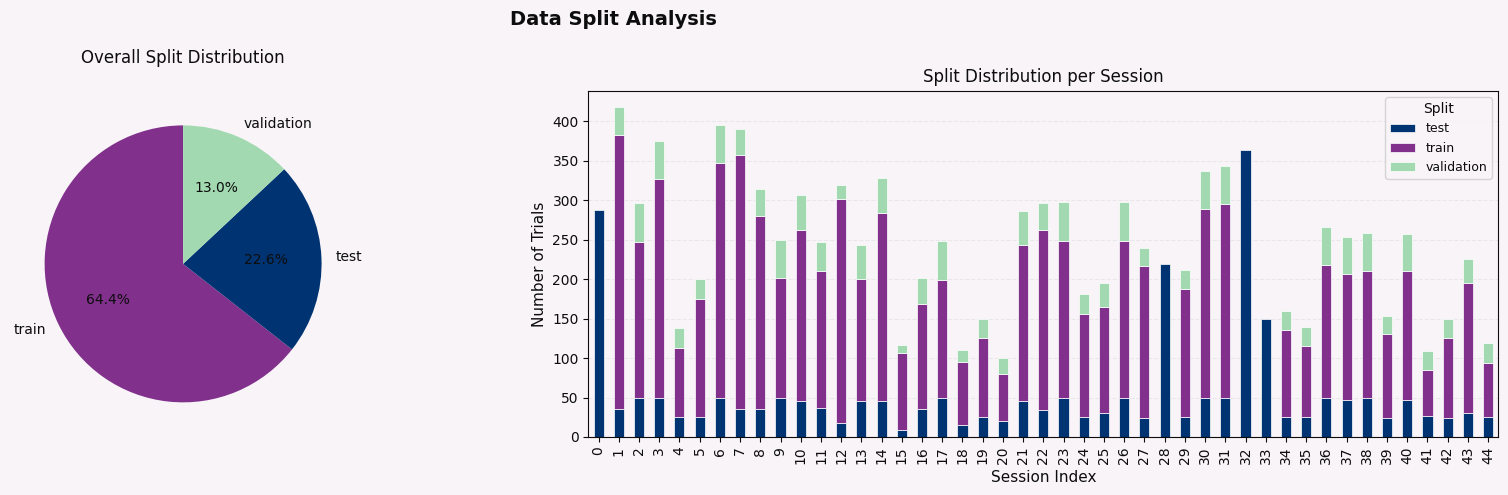

In [3]:
# ============================================================================
# PART 2: DATA SPLIT ANALYSIS (Plots 1, 2, 3)
# ============================================================================

print("\n" + "="*60)
print("PART 2: DATA SPLIT ANALYSIS")
print("="*60)

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 5))
fig2.suptitle('Data Split Analysis', fontsize=14, fontweight='bold', color=CUSTOM_COLORS['dark'])

# Plot 1: Split distribution pie chart
split_counts = df['split'].value_counts()
# Primary for train, secondary for test, green for validation
colors_split = [CUSTOM_COLORS['primary'], CUSTOM_COLORS['secondary'], '#A3D9B1']
axes2[0].pie(split_counts.values, labels=split_counts.index, autopct='%1.1f%%',
             colors=colors_split, startangle=90, textprops={'color': CUSTOM_COLORS['dark']})
axes2[0].set_title('Overall Split Distribution', pad=20)


# Plot 2: Split distribution per session
colors_split = [CUSTOM_COLORS['secondary'], CUSTOM_COLORS['primary'], '#A3D9B1']
split_by_session = df.groupby(['session_idx', 'split']).size().unstack(fill_value=0)
split_by_session.plot(kind='bar', stacked=True, ax=axes2[1], 
                      color=colors_split, edgecolor='white', linewidth=0.5)
axes2[1].set_xlabel('Session Index')
axes2[1].set_ylabel('Number of Trials')
axes2[1].set_title('Split Distribution per Session')
axes2[1].legend(title='Split', fontsize=9)
axes2[1].grid(True, alpha=0.3, linestyle='--', axis='y')
axes2[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('./results/V2_split_analysis.png', dpi=300, bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
plt.show()


PART 3: PHONEME AND WORD ANALYSIS


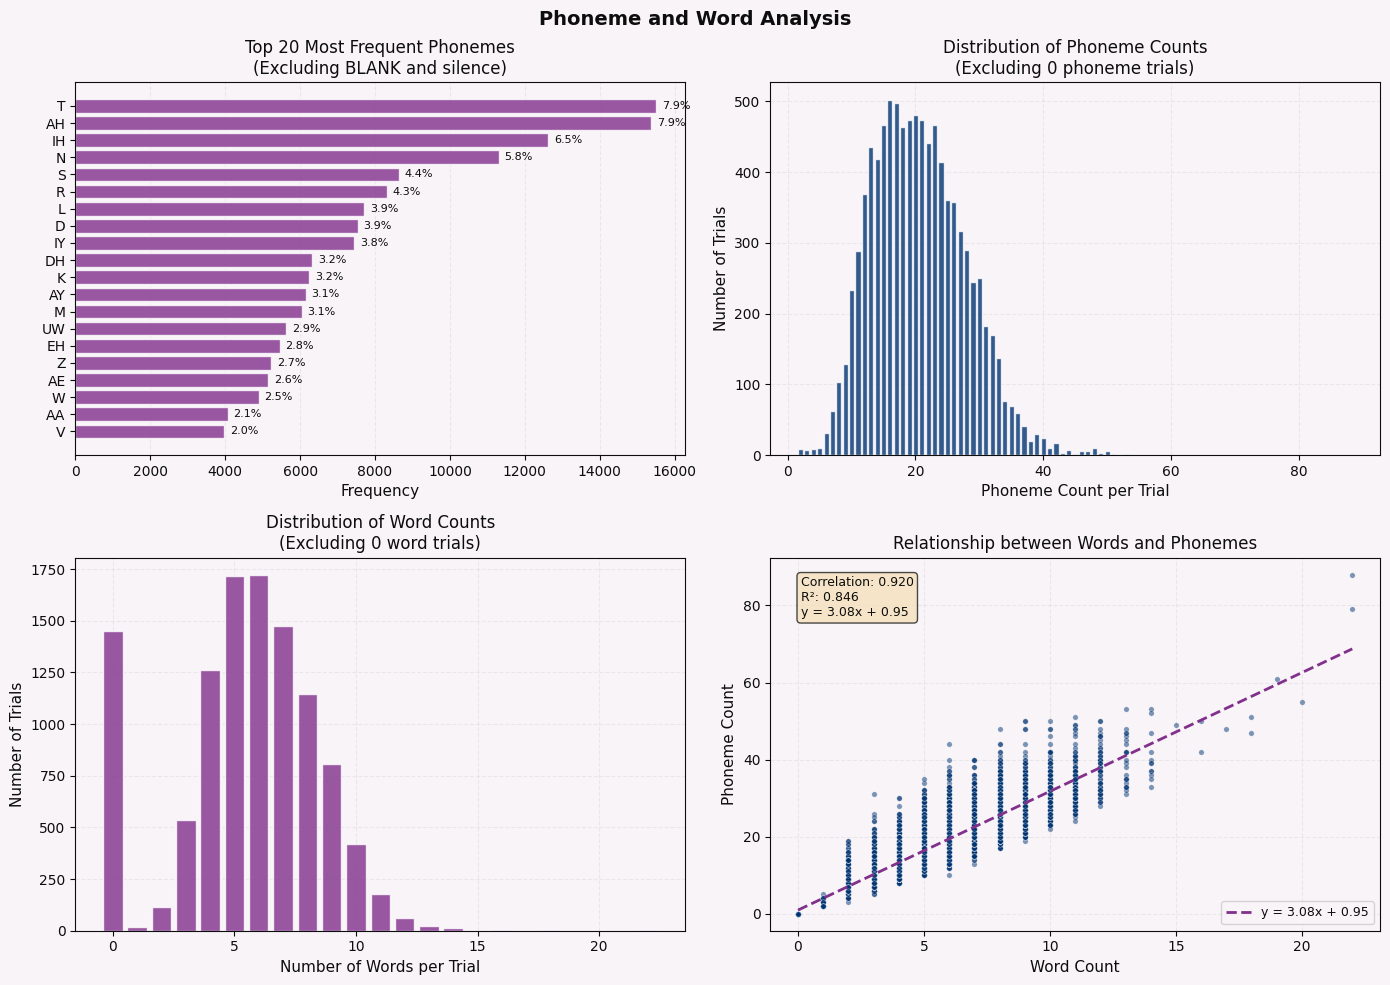

In [4]:
# ============================================================================
# PART 3: PHONEME AND WORD ANALYSIS (Plots 1, 2, 3, 4 with corrections)
# ============================================================================

print("\n" + "="*60)
print("PART 3: PHONEME AND WORD ANALYSIS")
print("="*60)

# Collect phoneme frequencies (excluding BLANK and ' | ')
all_phonemes = []
for phoneme_list in df['phoneme_sequence'].dropna():
    # Filter out BLANK and ' | '
    filtered_phonemes = [p for p in phoneme_list if p not in ['BLANK', ' | ']]
    all_phonemes.extend(filtered_phonemes)

phoneme_counts = Counter(all_phonemes)
total_phonemes = len(all_phonemes)

fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
fig3.suptitle('Phoneme and Word Analysis', fontsize=14, fontweight='bold', color=CUSTOM_COLORS['dark'])

# Plot 1: Most common phonemes (top 20, excluding BLANK and ' | ')
top_phonemes = phoneme_counts.most_common(20)
phoneme_names = [p[0] for p in top_phonemes]
phoneme_freqs = [p[1] for p in top_phonemes]

bars1 = axes3[0, 0].barh(range(len(phoneme_names)), phoneme_freqs, 
                         color=CUSTOM_COLORS['primary'], alpha=0.8, edgecolor='white')
axes3[0, 0].set_yticks(range(len(phoneme_names)))
axes3[0, 0].set_yticklabels(phoneme_names)
axes3[0, 0].set_xlabel('Frequency')
axes3[0, 0].set_title('Top 20 Most Frequent Phonemes\n(Excluding BLANK and silence)')
axes3[0, 0].invert_yaxis()
axes3[0, 0].grid(True, alpha=0.3, linestyle='--', axis='x')
axes3[0, 0].set_axisbelow(True)

# Add frequency percentages
for i, (bar, freq) in enumerate(zip(bars1, phoneme_freqs)):
    percentage = (freq / total_phonemes) * 100
    axes3[0, 0].text(freq + max(phoneme_freqs)*0.01, i, 
                    f'{percentage:.1f}%', va='center', fontsize=8)

# Plot 2: Phoneme distribution (remove 0 phoneme point)
# Filter out trials with 0 phonemes
df_phoneme_filtered = df[df['phoneme_count'] > 0]
phoneme_dist = df_phoneme_filtered['phoneme_count'].value_counts().sort_index()

axes3[0, 1].bar(phoneme_dist.index, phoneme_dist.values, 
                color=CUSTOM_COLORS['secondary'], alpha=0.8, edgecolor='white')
axes3[0, 1].set_xlabel('Phoneme Count per Trial')
axes3[0, 1].set_ylabel('Number of Trials')
axes3[0, 1].set_title('Distribution of Phoneme Counts\n(Excluding 0 phoneme trials)')
axes3[0, 1].grid(True, alpha=0.3, linestyle='--')
axes3[0, 1].set_axisbelow(True)

# Plot 3: Word length distribution (remove 0 word point)
# Filter out trials with 0 words
#df_word_filtered = df[df['word_count'] > 0]
word_lengths = df['word_count'].value_counts().sort_index()

axes3[1, 0].bar(word_lengths.index, word_lengths.values, 
                color=CUSTOM_COLORS['primary'], alpha=0.8, edgecolor='white')
axes3[1, 0].set_xlabel('Number of Words per Trial')
axes3[1, 0].set_ylabel('Number of Trials')
axes3[1, 0].set_title('Distribution of Word Counts\n(Excluding 0 word trials)')
axes3[1, 0].grid(True, alpha=0.3, linestyle='--')
axes3[1, 0].set_axisbelow(True)

# Plot 4: Relationship between Words and Phonemes (include all points)
df_corr_filtered = df

axes3[1, 1].scatter(df_corr_filtered['word_count'], df_corr_filtered['phoneme_count'], 
                    alpha=0.5, s=15, color=CUSTOM_COLORS['secondary'],
                    edgecolor='white', linewidth=0.3)
axes3[1, 1].set_xlabel('Word Count')
axes3[1, 1].set_ylabel('Phoneme Count')
axes3[1, 1].set_title('Relationship between Words and Phonemes')
axes3[1, 1].grid(True, alpha=0.3, linestyle='--')
axes3[1, 1].set_axisbelow(True)

# Add linear regression line
from scipy import stats

# Filter out NaN values for regression
regression_data = df_corr_filtered[['word_count', 'phoneme_count']].dropna()
if len(regression_data) > 1:
    x = regression_data['word_count']
    y = regression_data['phoneme_count']
    
    # Calculate linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Create line points
    x_line = np.array([x.min(), x.max()])
    y_line = slope * x_line + intercept
    
    # Plot regression line
    axes3[1, 1].plot(x_line, y_line, 
                     color=CUSTOM_COLORS['primary'], 
                     linewidth=2, 
                     linestyle='--',
                     label=f'y = {slope:.2f}x + {intercept:.2f}')
    
    # Update correlation text to include R²
    correlation = df_corr_filtered[['word_count', 'phoneme_count']].corr().iloc[0, 1]
    axes3[1, 1].text(0.05, 0.95, f'Correlation: {correlation:.3f}\nR²: {r_value**2:.3f}\ny = {slope:.2f}x + {intercept:.2f}', 
                    transform=axes3[1, 1].transAxes, fontsize=9,
                    verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # Add legend for regression line
    axes3[1, 1].legend(loc='lower right', fontsize=9)
else:
    # Calculate and display correlation only
    correlation = df_corr_filtered[['word_count', 'phoneme_count']].corr().iloc[0, 1]
    axes3[1, 1].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                    transform=axes3[1, 1].transAxes, fontsize=10,
                    verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('./results/V2_phoneme_word_analysis.png', dpi=300, bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
plt.show()


PART 4: NEURAL ACTIVITY DISTRIBUTION


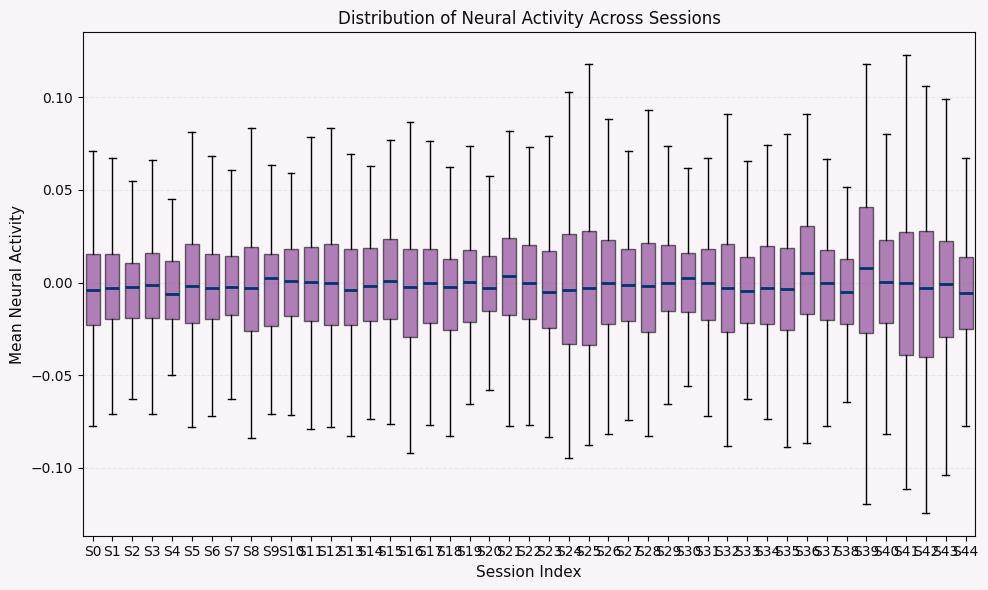

In [5]:

# ============================================================================
# PART 4: DISTRIBUTION OF NEURAL ACTIVITY ACROSS SESSIONS (Plot 3 only)
# ============================================================================

print("\n" + "="*60)
print("PART 4: NEURAL ACTIVITY DISTRIBUTION")
print("="*60)

fig4, ax4 = plt.subplots(1, 1, figsize=(10, 6))

# Prepare data for boxplot
session_data = []
session_labels = []
for session in sorted(df['session_idx'].unique()):
    session_neural = df[df['session_idx'] == session]['neural_mean'].values
    session_data.append(session_neural)
    session_labels.append(f'S{session}')

box = ax4.boxplot(session_data, patch_artist=True, showfliers=False, 
                  labels=session_labels, widths=0.7)

# Customize box colors
for patch in box['boxes']:
    patch.set_facecolor(CUSTOM_COLORS['primary'])
    patch.set_alpha(0.6)
    patch.set_edgecolor(CUSTOM_COLORS['dark'])

# Customize median lines
for median in box['medians']:
    median.set_color(CUSTOM_COLORS['secondary'])
    median.set_linewidth(2)

ax4.set_xlabel('Session Index')
ax4.set_ylabel('Mean Neural Activity')
ax4.set_title('Distribution of Neural Activity Across Sessions')
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')
ax4.set_axisbelow(True)

plt.tight_layout()
plt.savefig('./results/V2_neural_distribution.png', dpi=300, bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
plt.show()



PART 5: PHONEME AND SENTENCE EXAMPLES
Example trials showing phoneme sequences and transcriptions:

Example 1:
Session: 0, Block: 2, Trial: 0
Split: test
Phoneme sequence: BRIHNGIHTKLOWSER
Transcription: Bring it closer.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
Sentence Label: Bring it closer.
Word count: 3, Phoneme count: 11
----------------------------------------

Example 2:
Session: 0, Block: 2, Trial: 1
Split: test
Phoneme sequence: MAYFAEMAHLIYIHZKLOWSER
Transcription: My family is closer.                                                        

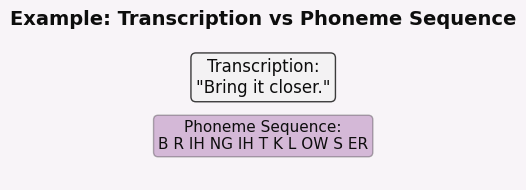

In [6]:


# ============================================================================
# PART 5: PHONEME AND SENTENCE EXAMPLES
# ============================================================================

print("\n" + "="*60)
print("PART 5: PHONEME AND SENTENCE EXAMPLES")
print("="*60)

# Find trials with both phonemes and transcriptions
valid_trials = df.dropna(subset=['phoneme_sequence', 'transcription'])
valid_trials = valid_trials[valid_trials['transcription'].str.len() > 0]

if len(valid_trials) > 0:
    # Take first few examples
    examples = valid_trials.head(5)
    
    print("Example trials showing phoneme sequences and transcriptions:")
    print("="*80)
    
    for idx, (_, row) in enumerate(examples.iterrows()):
        print(f"\nExample {idx+1}:")
        print(f"Session: {row['session_idx']}, Block: {row['block_num']}, Trial: {row['trial_num']}")
        print(f"Split: {row['split']}")
        print(f"Phoneme sequence: {''.join(row['phoneme_sequence'])}")
        print(f"Transcription: {row['transcription']}")
        print(f"Sentence Label: {row['sentence_label']}")
        print(f"Word count: {row['word_count']}, Phoneme count: {row['phoneme_count']}")
        print("-"*40)
else:
    print("No trials with both phonemes and transcriptions found.")

# Create a visualization showing phoneme alignment example
fig5, ax5 = plt.subplots(1, 1, figsize=(5, 2))

# Find a good example trial
example_trial = None
for _, row in valid_trials.iterrows():
    if len(row['phoneme_sequence']) > 5 and len(row['transcription']) > 10:
        example_trial = row
        break
# In Part 5 only - clean transcription for display
def clean_transcription(text):
    """Clean transcription text for display"""
    import re
    if not text:
        return ""
    # Remove digits and normalize
    cleaned = re.sub(r'[0-9]', '', text)
    cleaned = re.sub(r'\s+', ' ', cleaned)
    cleaned = cleaned.strip()
    # Limit length
    for i in range(len(cleaned)):
        if (cleaned[i] == cleaned[100]):
            cleaned = cleaned[:i]
            break
    return cleaned


if example_trial is not None:
    phonemes = example_trial['phoneme_sequence']
    text = example_trial['transcription']
    # Then use it in the display:
    display_text = clean_transcription(text)
    ax5.text(0.5, 0.7, f"Transcription:\n\"{display_text}\"", 
            fontsize=12, ha='center', va='center', 
            bbox=dict(boxstyle='round', facecolor=CUSTOM_COLORS['light'], alpha=0.8,
                    edgecolor=CUSTOM_COLORS['dark']))
    
    phoneme_str = ' '.join(phonemes)
    ax5.text(0.5, 0.3, f"Phoneme Sequence:\n{phoneme_str}", 
            fontsize=11, ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor=CUSTOM_COLORS['primary'], alpha=0.3,
                     edgecolor=CUSTOM_COLORS['dark']))
    
    ax5.set_title('Example: Transcription vs Phoneme Sequence', fontsize=14, fontweight='bold')
    ax5.axis('off')
    
    plt.tight_layout()
    plt.savefig('./results/V2_phoneme_example.png', dpi=300, bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
    plt.show()
else:
    print("Could not find suitable example for visualization.")



PART 6: NEURAL SIGNAL VISUALIZATION
✓ Sample neural data shape: (486, 512)
✓ Time steps: 486, Channels/Features: 512


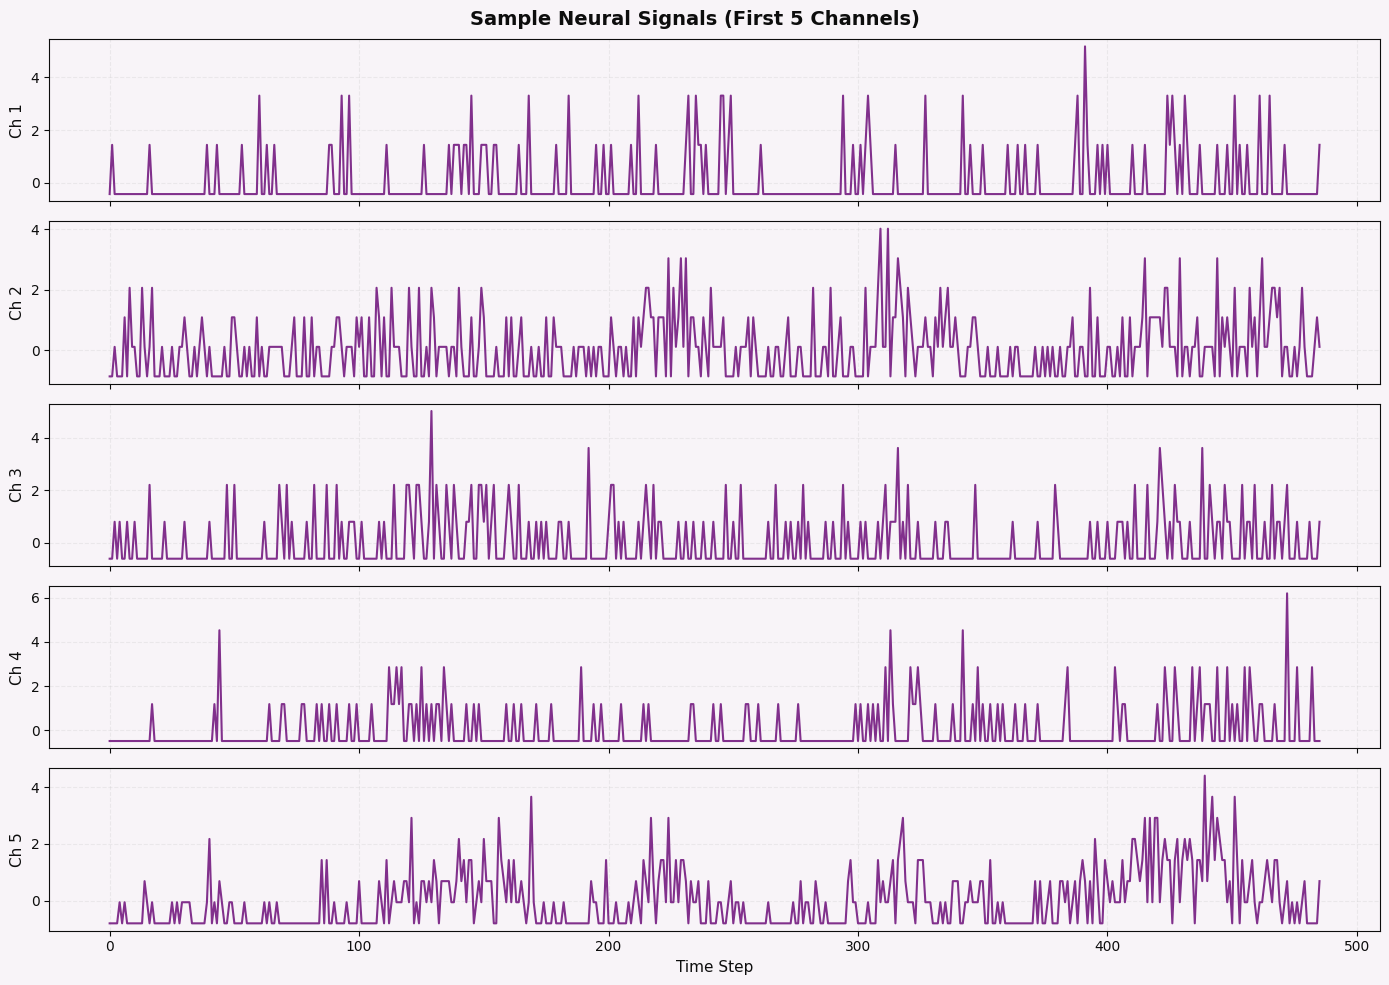


Calculating channel statistics across all sessions...
Calculating channel quality across all sessions...

=== CHANNEL QUALITY REPORT (Aggregated) ===
Total channels: 512
Mean variance across sessions: 1.000123
Std of variance across sessions: 0.030604
Consistently dead/saturated channels (< mean - 3σ): 3
  Indices: [246 295 308]
Consistently noisy channels (> mean + 3σ): 2
  Indices: [128 384]
Normal channels: 507


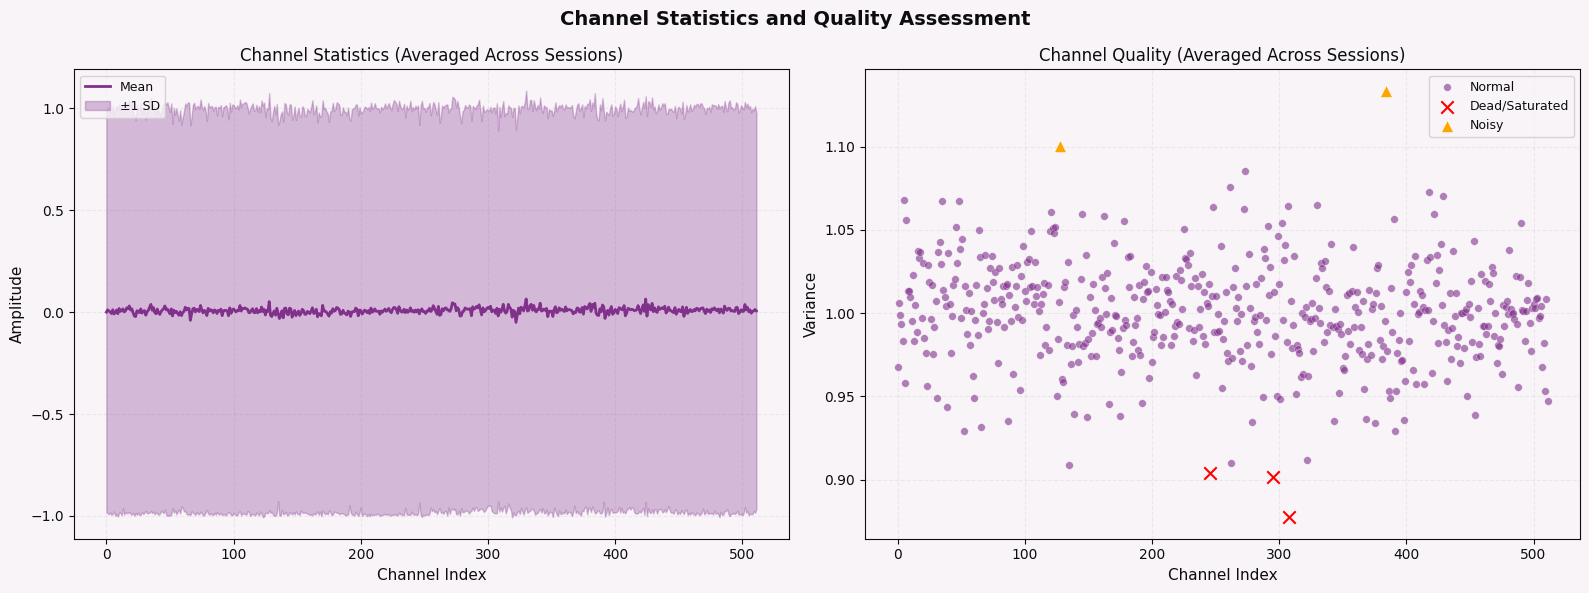

In [12]:
# ============================================================================
# PART 6: NEURAL SIGNAL VISUALIZATION (Plots 1, 2, 4)
# ============================================================================

print("\n" + "="*60)
print("PART 6: NEURAL SIGNAL VISUALIZATION")
print("="*60)

# Get sample neural data
session_idx = 2
split_idx = 1  # train
trial_idx = 0

if len(data) > session_idx and len(data[session_idx]) > split_idx:
    sample_neural = data[session_idx][split_idx]['neural_features'][trial_idx]
    print(f"✓ Sample neural data shape: {sample_neural.shape}")
    print(f"✓ Time steps: {sample_neural.shape[0]}, Channels/Features: {sample_neural.shape[1]}")
    
    # Create two separate figures
    # Figure 1: Individual channel plots (vertical layout)
    n_channels_to_show = min(5, sample_neural.shape[1])
    fig6a, axes6a = plt.subplots(n_channels_to_show, 1, figsize=(14, 10))
    fig6a.suptitle('Sample Neural Signals (First 5 Channels)', fontsize=14, fontweight='bold', color=CUSTOM_COLORS['dark'])
    
    time_steps = np.arange(sample_neural.shape[0])
    for i in range(n_channels_to_show):
        axes6a[i].plot(time_steps, sample_neural[:, i], 
                      color=CUSTOM_COLORS['primary'], linewidth=1.5)
        axes6a[i].set_ylabel(f'Ch {i+1}')
        axes6a[i].grid(True, alpha=0.3, linestyle='--')
        axes6a[i].set_axisbelow(True)
        
        # Only show x-label on bottom plot
        if i == n_channels_to_show - 1:
            axes6a[i].set_xlabel('Time Step')
        else:
            axes6a[i].set_xticklabels([])
    
    plt.tight_layout()
    plt.savefig('./results/V2_neural_signals_individual.png', dpi=300, bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
    plt.show()
    
    # Figure 2: Channel statistics and quality assessment (side by side)
    fig6b, axes6b = plt.subplots(1, 2, figsize=(16, 6))
    fig6b.suptitle('Channel Statistics and Quality Assessment', fontsize=14, fontweight='bold', color=CUSTOM_COLORS['dark'])
    
    # Plot 2: Channel statistics (averaged across all sessions)
    print("\nCalculating channel statistics across all sessions...")
    
    # Collect channel statistics from all sessions
    all_channel_means = []
    all_channel_stds = []
    
    for sess_idx in range(min(10, len(data))):  # Limit to first 10 sessions for speed
        for split_i in [0, 1, 2]:  # test, train, val
            if len(data[sess_idx]) > split_i:
                split_data = data[sess_idx][split_i]
                for trial_i in range(min(5, len(split_data['neural_features']))):  # Limit to 5 trials per split
                    neural_data = split_data['neural_features'][trial_i]
                    if neural_data.shape[1] == sample_neural.shape[1]:  # Same number of channels
                        all_channel_means.append(np.mean(neural_data, axis=0))
                        all_channel_stds.append(np.std(neural_data, axis=0))
    
    if all_channel_means:
        # Calculate average across all collected samples
        avg_channel_means = np.mean(all_channel_means, axis=0)
        avg_channel_stds = np.mean(all_channel_stds, axis=0)
        
        channels = np.arange(sample_neural.shape[1])
        axes6b[0].plot(channels, avg_channel_means, label='Mean', 
                      color=CUSTOM_COLORS['primary'], linewidth=2)
        axes6b[0].fill_between(channels, avg_channel_means - avg_channel_stds, 
                              avg_channel_means + avg_channel_stds,
                              alpha=0.3, color=CUSTOM_COLORS['primary'], label='±1 SD')
        axes6b[0].set_xlabel('Channel Index')
        axes6b[0].set_ylabel('Amplitude')
        axes6b[0].set_title('Channel Statistics (Averaged Across Sessions)')
        axes6b[0].legend(fontsize=9)
        axes6b[0].grid(True, alpha=0.3, linestyle='--')
        axes6b[0].set_axisbelow(True)
    else:
        # Fallback to single session if can't calculate averages
        channel_means = np.mean(sample_neural, axis=0)
        channel_stds = np.std(sample_neural, axis=0)
        channels = np.arange(sample_neural.shape[1])
        axes6b[0].plot(channels, channel_means, label='Mean', 
                      color=CUSTOM_COLORS['primary'], linewidth=2)
        axes6b[0].fill_between(channels, channel_means - channel_stds, channel_means + channel_stds,
                              alpha=0.3, color=CUSTOM_COLORS['primary'], label='±1 SD')
        axes6b[0].set_xlabel('Channel Index')
        axes6b[0].set_ylabel('Amplitude')
        axes6b[0].set_title('Channel Statistics (Single Session)')
        axes6b[0].legend(fontsize=9)
        axes6b[0].grid(True, alpha=0.3, linestyle='--')
        axes6b[0].set_axisbelow(True)
    
    # Plot 4: Channel quality assessment (averaged across all sessions)
    print("Calculating channel quality across all sessions...")
    
    # Collect channel variances from all sessions
    all_channel_variances = []
    
    for sess_idx in range(min(10, len(data))):  # Limit to first 10 sessions for speed
        for split_i in [0, 1, 2]:  # test, train, val
            if len(data[sess_idx]) > split_i:
                split_data = data[sess_idx][split_i]
                for trial_i in range(min(3, len(split_data['neural_features']))):  # Limit to 3 trials
                    neural_data = split_data['neural_features'][trial_i]
                    if neural_data.shape[1] == sample_neural.shape[1]:
                        all_channel_variances.append(np.var(neural_data, axis=0))
    
    if all_channel_variances:
        # Calculate average variance across all samples
        avg_channel_variance = np.mean(all_channel_variances, axis=0)
        mean_variance = np.mean(avg_channel_variance)
        std_variance = np.std(avg_channel_variance)
        
        # Identify outliers based on aggregated statistics
        dead_channels = np.where(avg_channel_variance < mean_variance - 3*std_variance)[0]
        noisy_channels = np.where(avg_channel_variance > mean_variance + 3*std_variance)[0]
        normal_mask = np.ones_like(avg_channel_variance, dtype=bool)
        
        if len(dead_channels) > 0:
            normal_mask[dead_channels] = False
        if len(noisy_channels) > 0:
            normal_mask[noisy_channels] = False
        
        channels = np.arange(sample_neural.shape[1])
        axes6b[1].scatter(channels[normal_mask], avg_channel_variance[normal_mask], 
                         alpha=0.6, s=30, color=CUSTOM_COLORS['primary'], label='Normal',
                         edgecolor='white', linewidth=0.3)
        
        if len(dead_channels) > 0:
            axes6b[1].scatter(dead_channels, avg_channel_variance[dead_channels], 
                             alpha=1.0, s=80, color='red', marker='x', label='Dead/Saturated',
                             linewidth=1.5)
        
        if len(noisy_channels) > 0:
            axes6b[1].scatter(noisy_channels, avg_channel_variance[noisy_channels], 
                             alpha=1.0, s=80, color='orange', marker='^', label='Noisy',
                             edgecolor='white', linewidth=0.5)
        
        axes6b[1].set_xlabel('Channel Index')
        axes6b[1].set_ylabel('Variance')
        axes6b[1].set_title('Channel Quality (Averaged Across Sessions)')
        axes6b[1].legend(fontsize=9)
        axes6b[1].grid(True, alpha=0.3, linestyle='--')
        axes6b[1].set_axisbelow(True)
        
        # Print channel quality report based on aggregated data
        print("\n=== CHANNEL QUALITY REPORT (Aggregated) ===")
        print(f"Total channels: {sample_neural.shape[1]}")
        print(f"Mean variance across sessions: {mean_variance:.6f}")
        print(f"Std of variance across sessions: {std_variance:.6f}")
        print(f"Consistently dead/saturated channels (< mean - 3σ): {len(dead_channels)}")
        if len(dead_channels) > 0:
            print(f"  Indices: {dead_channels[:10]}{'...' if len(dead_channels) > 10 else ''}")
        print(f"Consistently noisy channels (> mean + 3σ): {len(noisy_channels)}")
        if len(noisy_channels) > 0:
            print(f"  Indices: {noisy_channels[:10]}{'...' if len(noisy_channels) > 10 else ''}")
        print(f"Normal channels: {np.sum(normal_mask)}")
        
    else:
        # Fallback to single session
        channel_variance = np.var(sample_neural, axis=0)
        mean_variance = np.mean(channel_variance)
        std_variance = np.std(channel_variance)
        
        dead_channels = np.where(channel_variance < mean_variance - 3*std_variance)[0]
        noisy_channels = np.where(channel_variance > mean_variance + 3*std_variance)[0]
        normal_mask = np.ones_like(channel_variance, dtype=bool)
        
        if len(dead_channels) > 0:
            normal_mask[dead_channels] = False
        if len(noisy_channels) > 0:
            normal_mask[noisy_channels] = False
        
        channels = np.arange(sample_neural.shape[1])
        axes6b[1].scatter(channels[normal_mask], channel_variance[normal_mask], 
                         alpha=0.6, s=30, color=CUSTOM_COLORS['primary'], label='Normal',
                         edgecolor='white', linewidth=0.3)
        
        if len(dead_channels) > 0:
            axes6b[1].scatter(dead_channels, channel_variance[dead_channels], 
                             alpha=1.0, s=80, color='red', marker='x', label='Dead/Saturated',
                             linewidth=1.5)
        
        if len(noisy_channels) > 0:
            axes6b[1].scatter(noisy_channels, channel_variance[noisy_channels], 
                             alpha=1.0, s=80, color='orange', marker='^', label='Noisy',
                             edgecolor='white', linewidth=0.5)
        
        axes6b[1].set_xlabel('Channel Index')
        axes6b[1].set_ylabel('Variance')
        axes6b[1].set_title('Channel Quality (Single Session)')
        axes6b[1].legend(fontsize=9)
        axes6b[1].grid(True, alpha=0.3, linestyle='--')
        axes6b[1].set_axisbelow(True)
    
    plt.tight_layout()
    plt.savefig('./results/V2_channel_statistics_quality.png', dpi=300, bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
    plt.show()
    
else:
    print("✗ Could not access sample neural data from data structure")


PART 7: TEMPORAL ALIGNMENT


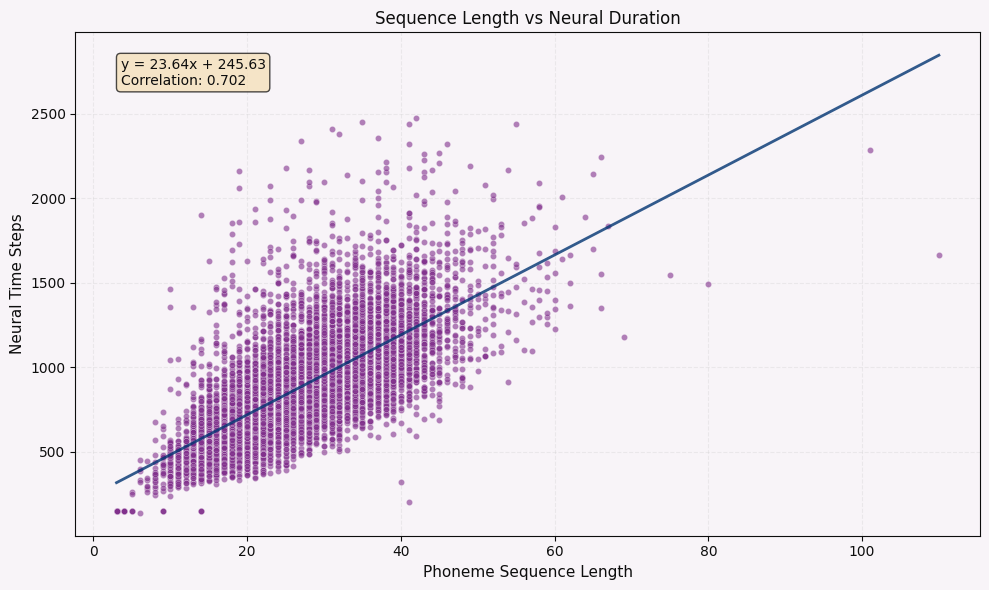

In [8]:

# ============================================================================
# PART 7: TEMPORAL ALIGNMENT (Plot 1 only)
# ============================================================================

print("\n" + "="*60)
print("PART 7: TEMPORAL ALIGNMENT")
print("="*60)

fig7, ax7 = plt.subplots(1, 1, figsize=(10, 6))

# Sequence length vs neural duration
valid_lengths = df.dropna(subset=['seq_len', 'n_time_steps'])
valid_lengths = valid_lengths[valid_lengths['seq_len'] > 0]

ax7.scatter(valid_lengths['seq_len'], valid_lengths['n_time_steps'],
            alpha=0.6, s=20, color=CUSTOM_COLORS['primary'],
            edgecolor='white', linewidth=0.3)
ax7.set_xlabel('Phoneme Sequence Length')
ax7.set_ylabel('Neural Time Steps')
ax7.set_title('Sequence Length vs Neural Duration')
ax7.grid(True, alpha=0.3, linestyle='--')
ax7.set_axisbelow(True)

# Add regression line
if len(valid_lengths) > 1:
    z = np.polyfit(valid_lengths['seq_len'], valid_lengths['n_time_steps'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(valid_lengths['seq_len'].min(), valid_lengths['seq_len'].max(), 100)
    ax7.plot(x_range, p(x_range), color=CUSTOM_COLORS['secondary'], linewidth=2, alpha=0.8)
    
    # Add equation text
    eq_text = f'y = {z[0]:.2f}x + {z[1]:.2f}'
    correlation = np.corrcoef(valid_lengths['seq_len'], valid_lengths['n_time_steps'])[0, 1]
    stats_text = f'Correlation: {correlation:.3f}'
    
    ax7.text(0.05, 0.95, eq_text + '\n' + stats_text, transform=ax7.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('./results/V2_temporal_alignment.png', dpi=300, bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
plt.show()



PART 8: ADDITIONAL ANALYSES


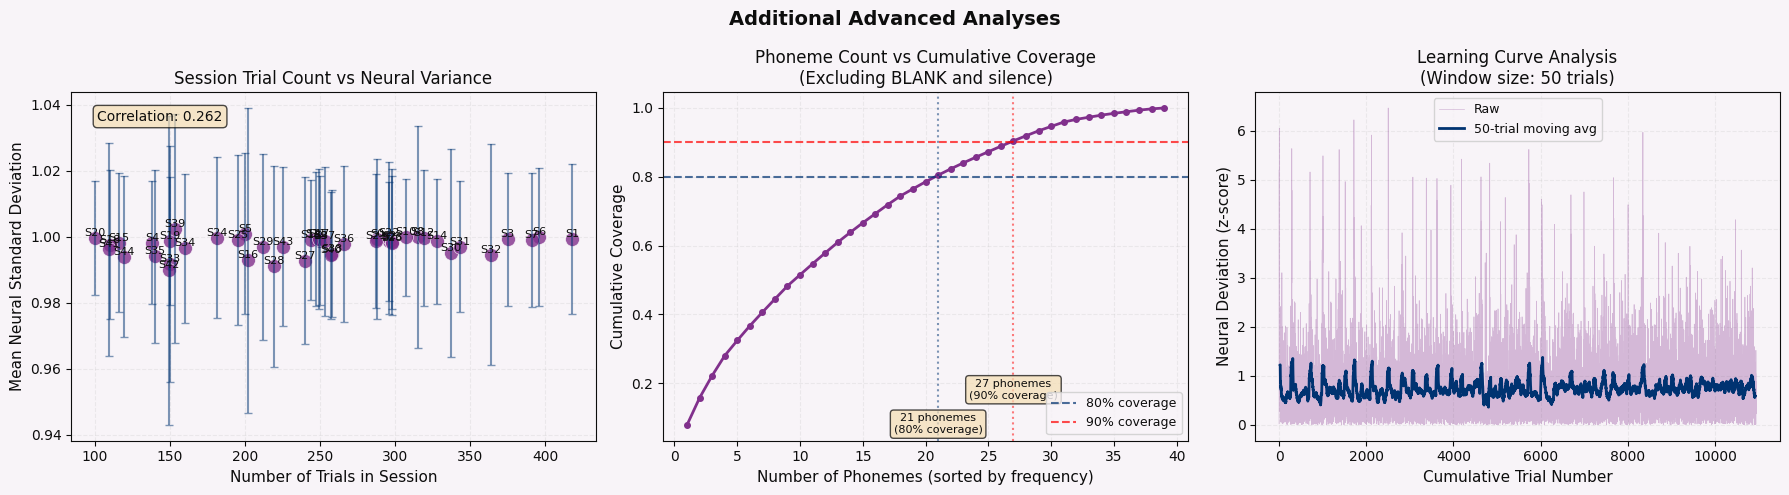


ANALYSIS COMPLETE!

All plots have been saved as PNG files:
1. temporal_distribution.png
2. split_analysis.png
3. phoneme_word_analysis.png
4. neural_distribution.png
5. phoneme_example.png
6. neural_signal_analysis.png
7. temporal_alignment.png
8. additional_analyses.png


In [9]:

# ============================================================================
# PART 8: ADDITIONAL ANALYSES (Plots 1, 2, 4)
# ============================================================================

print("\n" + "="*60)
print("PART 8: ADDITIONAL ANALYSES")
print("="*60)

fig8, axes8 = plt.subplots(1, 3, figsize=(18, 5))
fig8.suptitle('Additional Advanced Analyses', fontsize=14, fontweight='bold', color=CUSTOM_COLORS['dark'])

# Plot 1: Session count against neural variance
session_variance = df.groupby('session_idx')['neural_std'].agg(['mean', 'std']).reset_index()
session_variance.columns = ['session_idx', 'mean_std', 'std_std']
session_trial_counts = df.groupby('session_idx').size().reset_index(name='trial_count')
session_stats = pd.merge(session_variance, session_trial_counts, on='session_idx')

axes8[0].scatter(session_stats['trial_count'], session_stats['mean_std'], 
                 s=100, alpha=0.8, color=CUSTOM_COLORS['primary'],
                 edgecolor='white', linewidth=0.5)
axes8[0].errorbar(session_stats['trial_count'], session_stats['mean_std'],
                  yerr=session_stats['std_std'], fmt='none', 
                  ecolor=CUSTOM_COLORS['secondary'], alpha=0.5, capsize=3)
axes8[0].set_xlabel('Number of Trials in Session')
axes8[0].set_ylabel('Mean Neural Standard Deviation')
axes8[0].set_title('Session Trial Count vs Neural Variance')
axes8[0].grid(True, alpha=0.3, linestyle='--')
axes8[0].set_axisbelow(True)

for i, row in session_stats.iterrows():
    axes8[0].text(row['trial_count'], row['mean_std'], f'S{int(row["session_idx"])}', 
                 fontsize=8, ha='center', va='bottom')

corr_trial_variance = np.corrcoef(session_stats['trial_count'], session_stats['mean_std'])[0, 1]
axes8[0].text(0.05, 0.95, f'Correlation: {corr_trial_variance:.3f}', 
             transform=axes8[0].transAxes, fontsize=10,
             verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Plot 2: Phoneme count vs cumulative coverage
all_phonemes_filtered = [p for p in all_phonemes if p not in ['BLANK', ' | ']]
phoneme_counts_filtered = Counter(all_phonemes_filtered)
sorted_phonemes = phoneme_counts_filtered.most_common()
phoneme_names = [p[0] for p in sorted_phonemes]
phoneme_freqs = [p[1] for p in sorted_phonemes]
cumulative_counts = np.cumsum(phoneme_freqs)
cumulative_coverage = cumulative_counts / total_phonemes
phoneme_indices = np.arange(1, len(phoneme_names) + 1)

axes8[1].plot(phoneme_indices, cumulative_coverage, 
              color=CUSTOM_COLORS['primary'], linewidth=2, marker='o', markersize=4)
axes8[1].set_xlabel('Number of Phonemes (sorted by frequency)')
axes8[1].set_ylabel('Cumulative Coverage')
axes8[1].set_title('Phoneme Count vs Cumulative Coverage\n(Excluding BLANK and silence)')
axes8[1].grid(True, alpha=0.3, linestyle='--')
axes8[1].set_axisbelow(True)

# Add important thresholds
axes8[1].axhline(y=0.8, color=CUSTOM_COLORS['secondary'], linestyle='--', alpha=0.7, 
                label='80% coverage')
axes8[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.7, 
                label='90% coverage')

# Find where thresholds are crossed
idx_80 = np.where(cumulative_coverage >= 0.8)[0][0] + 1
idx_90 = np.where(cumulative_coverage >= 0.9)[0][0] + 1

axes8[1].axvline(x=idx_80, color=CUSTOM_COLORS['secondary'], linestyle=':', alpha=0.5)
axes8[1].axvline(x=idx_90, color='red', linestyle=':', alpha=0.5)

axes8[1].text(idx_80, 0.05, f'{idx_80} phonemes\n(80% coverage)', 
             fontsize=8, ha='center', va='bottom',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
axes8[1].text(idx_90, 0.15, f'{idx_90} phonemes\n(90% coverage)', 
             fontsize=8, ha='center', va='bottom',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

axes8[1].legend(loc='lower right', fontsize=9)

# Plot 4: Learning curve analysis
df_sorted = df.sort_values(['session_idx', 'trial_num']).reset_index(drop=True)
df_sorted['cumulative_trial'] = range(len(df_sorted))
df_sorted['neural_deviation'] = df_sorted.groupby('session_idx')['neural_mean'].transform(
    lambda x: np.abs(x - x.mean()) / x.std()
)

window_size = min(50, len(df_sorted) // 10)
if window_size > 5:
    df_sorted['rolling_deviation'] = df_sorted['neural_deviation'].rolling(window=window_size, center=True).mean()
    
    axes8[2].plot(df_sorted['cumulative_trial'], df_sorted['neural_deviation'], 
                 alpha=0.3, color=CUSTOM_COLORS['primary'], linewidth=0.5, label='Raw')
    axes8[2].plot(df_sorted['cumulative_trial'], df_sorted['rolling_deviation'], 
                 color=CUSTOM_COLORS['secondary'], linewidth=2, label=f'{window_size}-trial moving avg')
    axes8[2].set_xlabel('Cumulative Trial Number')
    axes8[2].set_ylabel('Neural Deviation (z-score)')
    axes8[2].set_title(f'Learning Curve Analysis\n(Window size: {window_size} trials)')
    axes8[2].legend(fontsize=9)
    axes8[2].grid(True, alpha=0.3, linestyle='--')
    axes8[2].set_axisbelow(True)
else:
    axes8[2].text(0.5, 0.5, 'Insufficient data\nfor learning curve analysis', 
                 ha='center', va='center', transform=axes8[2].transAxes,
                 fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    axes8[2].set_title('Learning Curve Analysis')
    axes8[2].axis('off')

plt.tight_layout()
plt.savefig('./results/V2_additional_analyses.png', dpi=300, bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print("\nAll plots have been saved as PNG files:")
print("1. temporal_distribution.png")
print("2. split_analysis.png")
print("3. phoneme_word_analysis.png")
print("4. neural_distribution.png")
print("5. phoneme_example.png")
print("6. neural_signal_analysis.png")
print("7. temporal_alignment.png")
print("8. additional_analyses.png")

In [14]:
# ============================================================================
# TOP 20 SENTENCES FREQUENCY (TEXT ONLY)
# ============================================================================

print("\n" + "="*60)
print("TOP 20 SENTENCES FREQUENCY")
print("="*60)

# Clean sentences (reusing your cleaning function)
def clean_sentence(text):
    import re
    if not text or not isinstance(text, str):
        return ""
    cleaned = re.sub(r'[0-9]', '', text)
    cleaned = re.sub(r'\s+', ' ', cleaned)
    cleaned = cleaned.strip().lower()
    return cleaned

df['cleaned_transcription'] = df['transcription'].apply(clean_sentence)
valid_sentences = df[df['cleaned_transcription'].str.len() > 0]

if len(valid_sentences) > 0:
    sentence_counts = valid_sentences['cleaned_transcription'].value_counts()
    top_20 = sentence_counts.head(20)
    
    print(f"\nTop 20 Most Frequent Sentences:")
    print("-" * 80)
    for i, (sentence, count) in enumerate(top_20.items(), 1):
        percentage = (count / len(valid_sentences)) * 100
        print(f"{i:2d}. '{sentence[:50]}{'...' if len(sentence) > 50 else ''}'")
        print(f"    Count: {count} ({percentage:.1f}% of trials)")
        print()
else:
    print("No valid sentences found.")


TOP 20 SENTENCES FREQUENCY

Top 20 Most Frequent Sentences:
--------------------------------------------------------------------------------
 1. 'she has had really good luck this year.           ...'
    Count: 6 (0.1% of trials)

 2. 'i hope everything works out up there.             ...'
    Count: 6 (0.1% of trials)

 3. 'are you pleased with this decision?               ...'
    Count: 6 (0.1% of trials)

 4. 'the town is just over the hill here.              ...'
    Count: 6 (0.1% of trials)

 5. 'in other words, there is a choice to make.        ...'
    Count: 6 (0.1% of trials)

 6. 'that does not seem quite fair.                    ...'
    Count: 6 (0.1% of trials)

 7. 'that is horrible.                                 ...'
    Count: 6 (0.1% of trials)

 8. 'fill the jar to the top with boiling water.       ...'
    Count: 6 (0.1% of trials)

 9. 'it was a prime time football game.                ...'
    Count: 6 (0.1% of trials)

10. 'not too long ago.                 


SIGNAL DIFFERENCES: SAME CHANNEL & SENTENCE

Could not find matching trials with same sentence and accessible neural data.
Trying alternative approach with sentence labels...

Found 3 trials with sentence_label: A bunch of psychiatrists are hanging out.

Analyzing sentence_label She has had really good luck this year. (6 trials)
Signal shapes: (100, 512)
Using middle channel for comparison


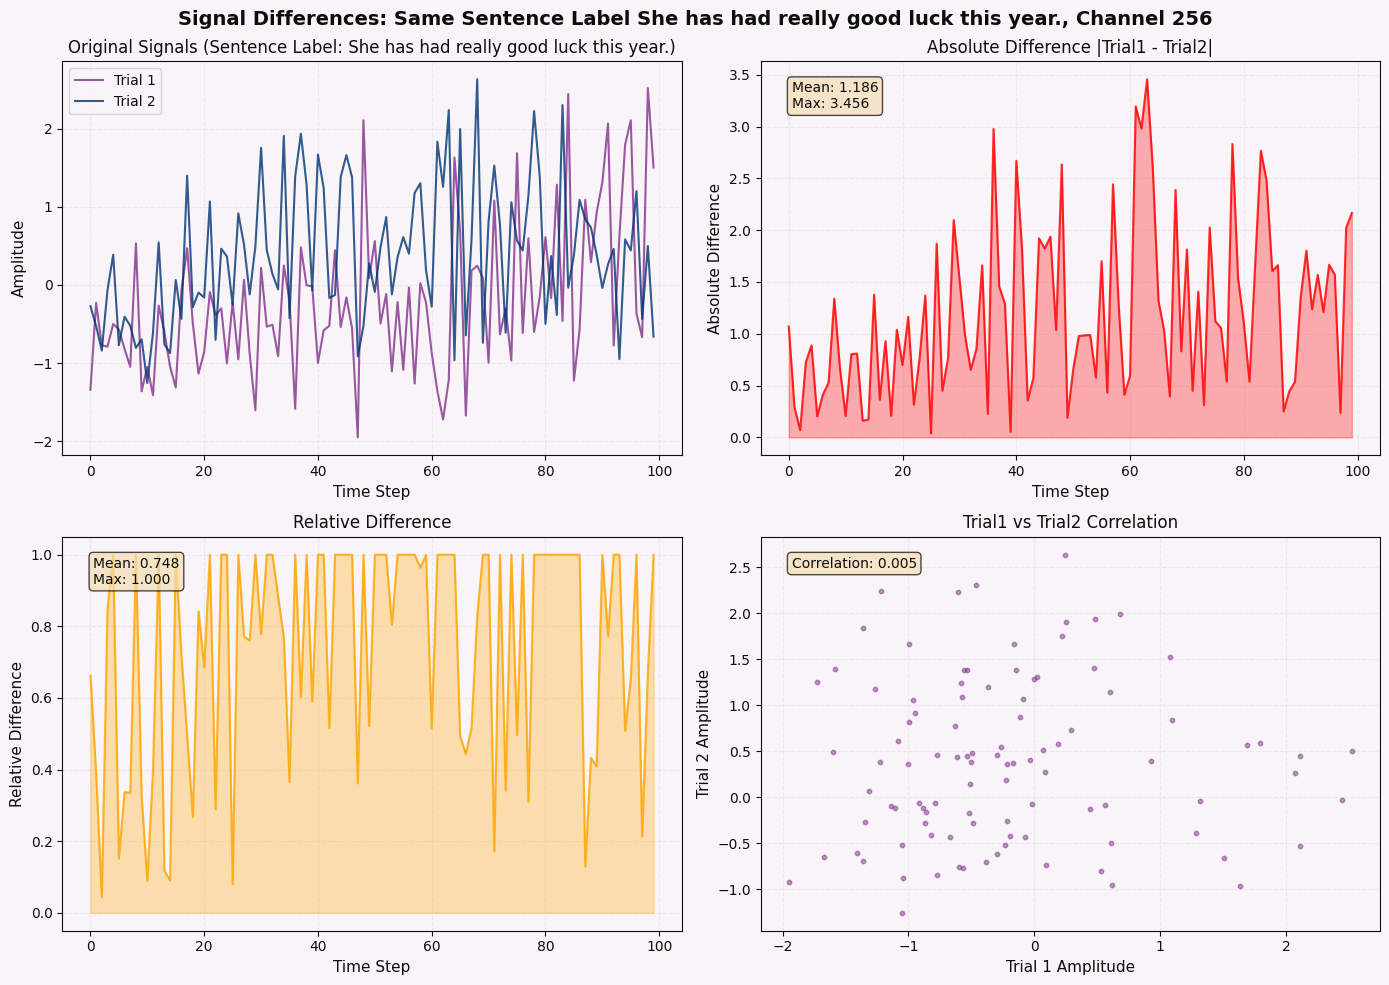


DIFFERENCE STATISTICS (Sentence Label Approach):
Absolute Difference:
  Mean: 1.186007, Std: 0.812042
  Max: 3.456446, Min: 0.037578

Relative Difference:
  Mean: 0.747535, Std: 0.309954
  Max: 1.000000, Min: 0.042984

Signal Correlation: 0.005

ANALYSIS COMPLETE


In [19]:
# ============================================================================
# SIGNAL DIFFERENCES FOR SAME CHANNEL & SENTENCE
# ============================================================================

print("\n" + "="*60)
print("SIGNAL DIFFERENCES: SAME CHANNEL & SENTENCE")
print("="*60)

def find_matching_trials():
    """Find trials with same sentence and channel count"""
    # Group by cleaned sentence
    sentence_groups = df.groupby('cleaned_transcription')
    
    for sentence, group in sentence_groups:
        if len(group) >= 2:  # Need at least 2 trials of same sentence
            # Check if we can access the neural data
            trials_data = []
            for idx, row in group.iterrows():
                session_idx = int(row['session_idx'])
                split_idx = {'train': 1, 'test': 0, 'validation': 2}[row['split']]
                trial_idx = int(row['trial_num'] - 1)  # Convert to 0-based
                
                try:
                    if (len(data) > session_idx and 
                        len(data[session_idx]) > split_idx and
                        len(data[session_idx][split_idx]['neural_features']) > trial_idx):
                        
                        neural_data = data[session_idx][split_idx]['neural_features'][trial_idx]
                        trials_data.append({
                            'neural': neural_data,
                            'session': session_idx,
                            'trial': trial_idx
                        })
                except:
                    continue
            
            if len(trials_data) >= 2:
                return sentence, trials_data[:2]  # Return first 2 matching trials
    
    return None, None

# Find matching trials
sentence, trials_data = find_matching_trials()

if sentence and trials_data:
    print(f"\nFound matching sentence: '{sentence[:50]}{'...' if len(sentence) > 50 else ''}'")
    print(f"Trial 1: Session {trials_data[0]['session']}, Trial {trials_data[0]['trial']}")
    print(f"Trial 2: Session {trials_data[1]['session']}, Trial {trials_data[1]['trial']}")
    
    # Get neural signals
    signal1 = trials_data[0]['neural']
    signal2 = trials_data[1]['neural']
    
    # Ensure same shape (take min length)
    min_length = min(signal1.shape[0], signal2.shape[0],100)
    signal1 = signal1[:min_length, :]
    signal2 = signal2[:min_length, :]
    
    print(f"\nSignal shapes: {signal1.shape}")
    print(f"Number of channels: {signal1.shape[1]}")
    
    # Select a channel to analyze (middle channel)
    channel_idx = signal1.shape[1] // 2
    
    # Extract channel data
    ch1 = signal1[:, channel_idx]
    ch2 = signal2[:, channel_idx]
    time_steps = np.arange(min_length)
    
    # Calculate differences
    absolute_diff = np.abs(ch1 - ch2)
    relative_diff = absolute_diff / (np.abs(ch1) + np.abs(ch2) + 1e-10)  # Add small epsilon to avoid division by zero
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Signal Differences: Same Sentence, Channel {channel_idx}', 
                fontsize=14, fontweight='bold', color=CUSTOM_COLORS['dark'])
    
    # Plot 1: Original signals
    axes[0, 0].plot(time_steps, ch1, color=CUSTOM_COLORS['primary'], 
                   label='Trial 1', linewidth=1.5, alpha=0.8)
    axes[0, 0].plot(time_steps, ch2, color=CUSTOM_COLORS['secondary'], 
                   label='Trial 2', linewidth=1.5, alpha=0.8)
    axes[0, 0].set_xlabel('Time Step')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].set_title('Original Signals (Same Channel)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, linestyle='--')
    axes[0, 0].set_axisbelow(True)
    
    # Plot 2: Absolute difference
    axes[0, 1].plot(time_steps, absolute_diff, color='red', 
                   linewidth=1.5, alpha=0.8)
    axes[0, 1].fill_between(time_steps, 0, absolute_diff, 
                           color='red', alpha=0.3)
    axes[0, 1].set_xlabel('Time Step')
    axes[0, 1].set_ylabel('Absolute Difference')
    axes[0, 1].set_title('Absolute Difference |Trial1 - Trial2|')
    axes[0, 1].grid(True, alpha=0.3, linestyle='--')
    axes[0, 1].set_axisbelow(True)
    
    # Add stats for absolute difference
    mean_abs = np.mean(absolute_diff)
    max_abs = np.max(absolute_diff)
    axes[0, 1].text(0.05, 0.95, f'Mean: {mean_abs:.3f}\nMax: {max_abs:.3f}', 
                   transform=axes[0, 1].transAxes, fontsize=10,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # Plot 3: Relative difference
    axes[1, 0].plot(time_steps, relative_diff, color='orange', 
                   linewidth=1.5, alpha=0.8)
    axes[1, 0].fill_between(time_steps, 0, relative_diff, 
                           color='orange', alpha=0.3)
    axes[1, 0].set_xlabel('Time Step')
    axes[1, 0].set_ylabel('Relative Difference')
    axes[1, 0].set_title('Relative Difference |Trial1 - Trial2| / (|Trial1| + |Trial2|)')
    axes[1, 0].grid(True, alpha=0.3, linestyle='--')
    axes[1, 0].set_axisbelow(True)
    
    # Add stats for relative difference
    mean_rel = np.mean(relative_diff)
    max_rel = np.max(relative_diff)
    axes[1, 0].text(0.05, 0.95, f'Mean: {mean_rel:.3f}\nMax: {max_rel:.3f}', 
                   transform=axes[1, 0].transAxes, fontsize=10,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # Plot 4: Distribution of differences
    axes[1, 1].hist(absolute_diff, bins=50, color=CUSTOM_COLORS['primary'], 
                   alpha=0.7, edgecolor='white', label='Absolute')
    axes[1, 1].hist(relative_diff, bins=50, color=CUSTOM_COLORS['secondary'], 
                   alpha=0.7, edgecolor='white', label='Relative')
    axes[1, 1].set_xlabel('Difference Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Differences')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, linestyle='--')
    axes[1, 1].set_axisbelow(True)
    
    plt.tight_layout()
    plt.savefig('./results/signal_differences_same_sentence.png', dpi=300, 
                bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("DIFFERENCE STATISTICS SUMMARY:")
    print("="*60)
    print(f"Absolute Difference:")
    print(f"  Mean: {mean_abs:.6f}")
    print(f"  Std: {np.std(absolute_diff):.6f}")
    print(f"  Max: {max_abs:.6f}")
    print(f"  Min: {np.min(absolute_diff):.6f}")
    print(f"\nRelative Difference:")
    print(f"  Mean: {mean_rel:.6f}")
    print(f"  Std: {np.std(relative_diff):.6f}")
    print(f"  Max: {max_rel:.6f}")
    print(f"  Min: {np.min(relative_diff):.6f}")
    
else:
    print("\nCould not find matching trials with same sentence and accessible neural data.")
    print("Trying alternative approach with sentence labels...")
    
    # Alternative: Use sentence_label if available
    if 'sentence_label' in df.columns:
        sentence_groups = df.groupby('sentence_label')
        for label, group in sentence_groups:
            if len(group) >= 2:
                print(f"\nFound {len(group)} trials with sentence_label: {label}")
                break
                    # Continue with sentence_label approach
        if 'sentence_label' in df.columns and df['sentence_label'].notna().any():
            # Find most common sentence label
            common_labels = df['sentence_label'].value_counts().head(5)
            
            for label, count in common_labels.items():
                if count >= 2:
                    print(f"\nAnalyzing sentence_label {label} ({count} trials)")
                    
                    # Get trials with this label
                    label_trials = df[df['sentence_label'] == label]
                    
                    # Try to access neural data for first 2 trials
                    trials_to_compare = []
                    for _, row in label_trials.head(2).iterrows():
                        try:
                            session_idx = int(row['session_idx'])
                            split_idx = {'train': 1, 'test': 0, 'validation': 2}[row['split']]
                            trial_idx = int(row['trial_num'] - 1)
                            
                            if (len(data) > session_idx and 
                                len(data[session_idx]) > split_idx and
                                len(data[session_idx][split_idx]['neural_features']) > trial_idx):
                                
                                neural_data = data[session_idx][split_idx]['neural_features'][trial_idx]
                                trials_to_compare.append(neural_data)
                        except:
                            continue
                    
                    if len(trials_to_compare) >= 2:
                        signal1 = trials_to_compare[0]
                        signal2 = trials_to_compare[1]
                        
                        # Ensure same shape
                        min_length = min(signal1.shape[0], signal2.shape[0],100)
                        min_channels = min(signal1.shape[1], signal2.shape[1])
                        signal1 = signal1[:min_length, :min_channels]
                        signal2 = signal2[:min_length, :min_channels]
                        
                        print(f"Signal shapes: {signal1.shape}")
                        print(f"Using middle channel for comparison")
                        
                        # Select middle channel
                        channel_idx = signal1.shape[1] // 2
                        ch1 = signal1[:, channel_idx]
                        ch2 = signal2[:, channel_idx]
                        time_steps = np.arange(min_length)
                        
                        # Calculate differences
                        absolute_diff = np.abs(ch1 - ch2)
                        relative_diff = absolute_diff / (np.abs(ch1) + np.abs(ch2) + 1e-10)
                        
                        # Create simplified figure
                        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
                        fig.suptitle(f'Signal Differences: Same Sentence Label {label}, Channel {channel_idx}', 
                                    fontsize=14, fontweight='bold', color=CUSTOM_COLORS['dark'])
                        
                        # Plot 1: Original signals
                        axes[0, 0].plot(time_steps, ch1, color=CUSTOM_COLORS['primary'], 
                                       label='Trial 1', linewidth=1.5, alpha=0.8)
                        axes[0, 0].plot(time_steps, ch2, color=CUSTOM_COLORS['secondary'], 
                                       label='Trial 2', linewidth=1.5, alpha=0.8)
                        axes[0, 0].set_xlabel('Time Step')
                        axes[0, 0].set_ylabel('Amplitude')
                        axes[0, 0].set_title(f'Original Signals (Sentence Label: {label})')
                        axes[0, 0].legend()
                        axes[0, 0].grid(True, alpha=0.3, linestyle='--')
                        axes[0, 0].set_axisbelow(True)
                        
                        # Plot 2: Absolute difference
                        axes[0, 1].plot(time_steps, absolute_diff, color='red', 
                                       linewidth=1.5, alpha=0.8)
                        axes[0, 1].fill_between(time_steps, 0, absolute_diff, 
                                               color='red', alpha=0.3)
                        axes[0, 1].set_xlabel('Time Step')
                        axes[0, 1].set_ylabel('Absolute Difference')
                        axes[0, 1].set_title('Absolute Difference |Trial1 - Trial2|')
                        axes[0, 1].grid(True, alpha=0.3, linestyle='--')
                        axes[0, 1].set_axisbelow(True)
                        
                        mean_abs = np.mean(absolute_diff)
                        max_abs = np.max(absolute_diff)
                        axes[0, 1].text(0.05, 0.95, f'Mean: {mean_abs:.3f}\nMax: {max_abs:.3f}', 
                                       transform=axes[0, 1].transAxes, fontsize=10,
                                       verticalalignment='top',
                                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
                        
                        # Plot 3: Relative difference
                        axes[1, 0].plot(time_steps, relative_diff, color='orange', 
                                       linewidth=1.5, alpha=0.8)
                        axes[1, 0].fill_between(time_steps, 0, relative_diff, 
                                               color='orange', alpha=0.3)
                        axes[1, 0].set_xlabel('Time Step')
                        axes[1, 0].set_ylabel('Relative Difference')
                        axes[1, 0].set_title('Relative Difference')
                        axes[1, 0].grid(True, alpha=0.3, linestyle='--')
                        axes[1, 0].set_axisbelow(True)
                        
                        mean_rel = np.mean(relative_diff)
                        max_rel = np.max(relative_diff)
                        axes[1, 0].text(0.05, 0.95, f'Mean: {mean_rel:.3f}\nMax: {max_rel:.3f}', 
                                       transform=axes[1, 0].transAxes, fontsize=10,
                                       verticalalignment='top',
                                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
                        
                        # Plot 4: Correlation scatter
                        axes[1, 1].scatter(ch1, ch2, alpha=0.5, s=10, 
                                          color=CUSTOM_COLORS['primary'])
                        axes[1, 1].set_xlabel('Trial 1 Amplitude')
                        axes[1, 1].set_ylabel('Trial 2 Amplitude')
                        axes[1, 1].set_title('Trial1 vs Trial2 Correlation')
                        axes[1, 1].grid(True, alpha=0.3, linestyle='--')
                        axes[1, 1].set_axisbelow(True)
                        
                        # Add correlation line
                        correlation = np.corrcoef(ch1, ch2)[0, 1]
                        axes[1, 1].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                                       transform=axes[1, 1].transAxes, fontsize=10,
                                       verticalalignment='top',
                                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
                        
                        plt.tight_layout()
                        plt.savefig('./results/signal_differences_same_label.png', dpi=300, 
                                    bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
                        plt.show()
                        
                        # Print summary
                        print("\n" + "="*60)
                        print("DIFFERENCE STATISTICS (Sentence Label Approach):")
                        print("="*60)
                        print(f"Absolute Difference:")
                        print(f"  Mean: {mean_abs:.6f}, Std: {np.std(absolute_diff):.6f}")
                        print(f"  Max: {max_abs:.6f}, Min: {np.min(absolute_diff):.6f}")
                        print(f"\nRelative Difference:")
                        print(f"  Mean: {mean_rel:.6f}, Std: {np.std(relative_diff):.6f}")
                        print(f"  Max: {max_rel:.6f}, Min: {np.min(relative_diff):.6f}")
                        print(f"\nSignal Correlation: {correlation:.3f}")
                        
                        break  # Stop after first successful comparison
                    else:
                        print(f"Could not access neural data for sentence_label {label}")
            else:
                print("No sentence label found with 2+ accessible trials")
        else:
            print("No sentence_label data available")
            
    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)


ADVANCED CHANNEL QUALITY DETECTION
Accessing your data structure...
✓ Found sample data at session 1, split 1
Processed session 1, total trials: 2
Processed session 2, total trials: 8
Processed session 3, total trials: 14

✓ Collected statistics from 14 trials across 3 sessions
✓ Number of channels: 512

SIMPLIFIED CHANNEL ANALYSIS ON SAMPLE DATA
Sample data shape: (1023, 512)
Time points: 1023
Channels: 512

Dead channels (< mean - 2σ): 11
Noisy channels (> variance + 2σ): 0
  Dead channel indices: [ 61 104 135 166 168 183 224 281 334 456 480]

FREQUENCY ANALYSIS ON SAMPLE CHANNELS


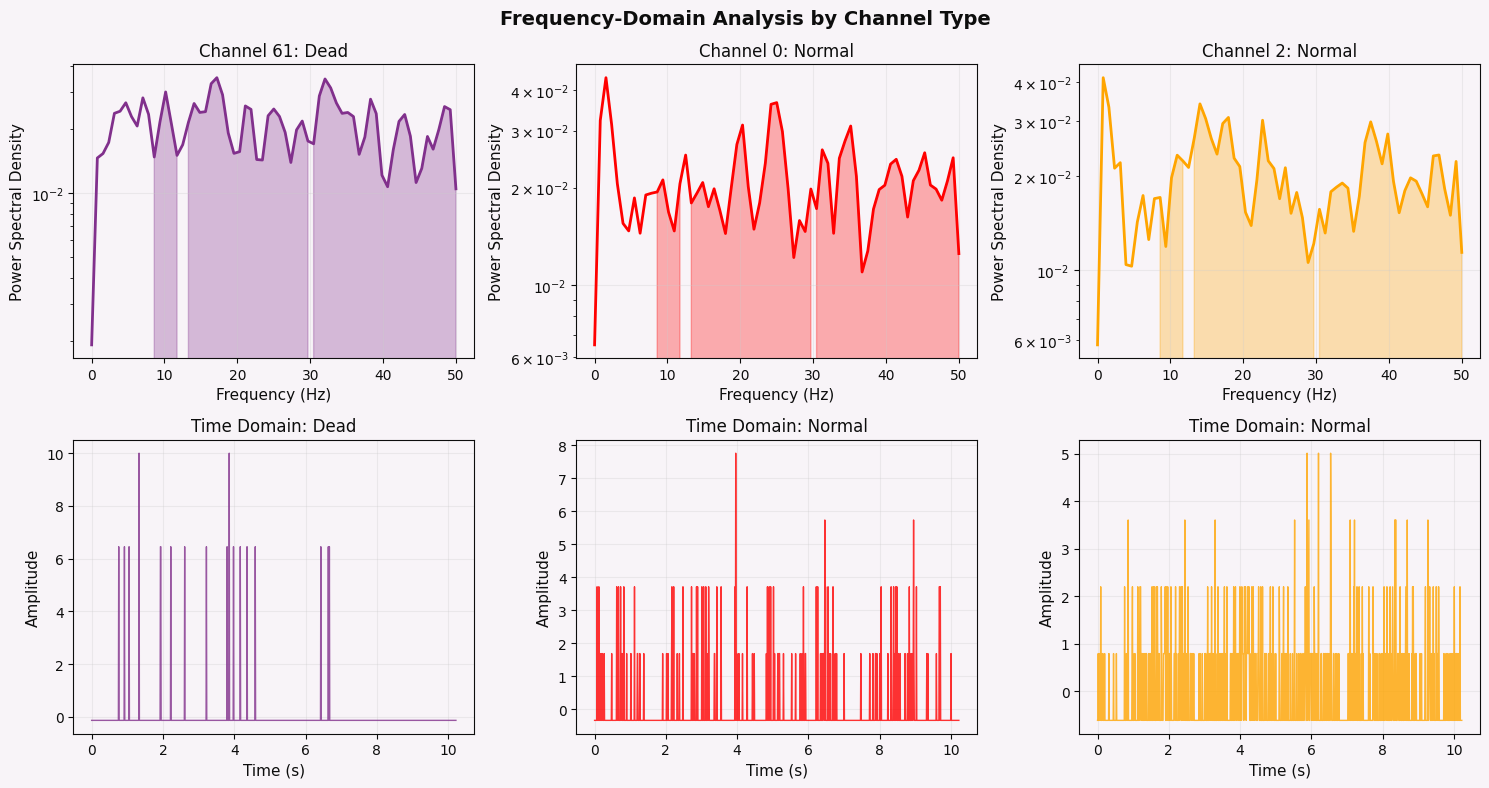


CHANNEL MASKING
Total channels: 512
Channels to keep: 501
Channels to exclude: 11
Excluded channel indices: [ 61 104 135 166 168 183 224 281 334 456 480]

Example masking:
  Original shape: (1023, 512)
  Masked shape: (1023, 501)

HOW TO USE CHANNEL MASKS DURING MODEL TRAINING

Option 1: Pre-process data before training
------------------------------------------
mask = ~dead_channels  # Boolean mask of good channels
processed_data = original_data[:, mask]

Option 2: Create a custom PyTorch/TensorFlow layer
--------------------------------------------------
class ChannelMaskLayer(nn.Module):
    def __init__(self, mask):
        super().__init__()
        self.mask = torch.tensor(mask, dtype=torch.bool)

    def forward(self, x):
        return x[:, self.mask]

Option 3: Weighted channels (soft masking)
------------------------------------------
weights = np.ones(n_channels)
weights[dead_channels] = 0.0
weights[noisy_channels] = 0.3

# In model: x * weights

Option 4: Interpolation of 

In [22]:
# ============================================================================
# ADVANCED PROBLEMATIC CHANNEL DETECTION (USING EXISTING DATA STRUCTURE)
# ============================================================================

print("\n" + "="*60)
print("ADVANCED CHANNEL QUALITY DETECTION")
print("="*60)

import numpy as np
from scipy import signal, stats
from scipy.stats import kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

def collect_channel_statistics_from_data(data, max_sessions=5, max_trials_per_session=3):
    """
    Collect comprehensive channel statistics using your data structure
    """
    all_stats = {
        'mean': [],      # Temporal mean per trial
        'std': [],       # Temporal std per trial
        'range': [],     # Max-min per trial
        'kurtosis': [],  # Temporal kurtosis per trial
        'skewness': [],  # Temporal skewness per trial
        'psd_alpha': [], # Power in alpha band (8-12 Hz)
        'psd_beta': [],  # Power in beta band (13-30 Hz)
        'psd_gamma': [], # Power in gamma band (30-80 Hz)
        'psd_total': [], # Total power
        'line_noise': [] # Power at 60 Hz (or 50 Hz)
    }
    
    # Get sampling rate from first trial's n_time_steps
    sampling_rate = 100  # Default, adjust if you know your actual sampling rate
    
    session_count = 0
    trial_count = 0
    
    for session_idx in range(min(max_sessions, len(data))):
        if len(data[session_idx]) == 0:
            continue
            
        for split_idx in range(min(3, len(data[session_idx]))):  # test, train, val
            split_data = data[session_idx][split_idx]
            
            # Check if this split has neural data
            if ('neural_features' not in split_data or 
                split_data['neural_features'] is None or 
                len(split_data['neural_features']) == 0):
                continue
            
            n_trials = min(max_trials_per_session, len(split_data['neural_features']))
            
            for trial_idx in range(n_trials):
                neural_data = split_data['neural_features'][trial_idx]
                n_channels = neural_data.shape[1]
                
                # Initialize arrays for this trial
                trial_stats = {key: np.zeros(n_channels) for key in all_stats.keys()}
                
                for ch in range(n_channels):
                    ch_signal = neural_data[:, ch]
                    
                    # Time-domain statistics
                    trial_stats['mean'][ch] = np.mean(ch_signal)
                    trial_stats['std'][ch] = np.std(ch_signal)
                    trial_stats['range'][ch] = np.max(ch_signal) - np.min(ch_signal)
                    
                    # Check if we have enough data points for kurtosis/skewness
                    if len(ch_signal) > 10:
                        trial_stats['kurtosis'][ch] = kurtosis(ch_signal)
                        trial_stats['skewness'][ch] = skew(ch_signal)
                    
                    # Frequency-domain statistics
                    if len(ch_signal) > 50:  # Need enough points for PSD
                        # Compute PSD
                        f, Pxx = signal.welch(ch_signal, fs=sampling_rate, 
                                              nperseg=min(128, len(ch_signal)))
                        
                        # Band power calculations
                        trial_stats['psd_total'][ch] = np.sum(Pxx)
                        
                        # Alpha band (8-12 Hz)
                        alpha_mask = (f >= 8) & (f <= 12)
                        trial_stats['psd_alpha'][ch] = np.sum(Pxx[alpha_mask]) if np.any(alpha_mask) else 0
                        
                        # Beta band (13-30 Hz)
                        beta_mask = (f >= 13) & (f <= 30)
                        trial_stats['psd_beta'][ch] = np.sum(Pxx[beta_mask]) if np.any(beta_mask) else 0
                        
                        # Gamma band (30-80 Hz)
                        gamma_mask = (f >= 30) & (f <= 80)
                        trial_stats['psd_gamma'][ch] = np.sum(Pxx[gamma_mask]) if np.any(gamma_mask) else 0
                        
                        # Line noise (60 Hz ± 2 Hz)
                        line_mask = (f >= 58) & (f <= 62)
                        trial_stats['line_noise'][ch] = np.sum(Pxx[line_mask]) if np.any(line_mask) else 0
                
                # Append all statistics
                for key in all_stats.keys():
                    all_stats[key].append(trial_stats[key])
                
                trial_count += 1
        
        session_count += 1
        print(f"Processed session {session_count}, total trials: {trial_count}")
        if session_count >= max_sessions:
            break
    
    # Convert to arrays
    for key in all_stats.keys():
        if all_stats[key]:  # Check if list is not empty
            all_stats[key] = np.array(all_stats[key])
        else:
            all_stats[key] = np.array([])
    
    print(f"\n✓ Collected statistics from {trial_count} trials across {session_count} sessions")
    return all_stats, sampling_rate

# Get the actual data structure - using what we know
print("Accessing your data structure...")

# Find a session that has data
sample_session_idx = None
sample_split_idx = None
sample_trial_idx = 0

for s_idx in range(min(5, len(data))):
    if len(data[s_idx]) > 1:  # Has at least train split
        if ('neural_features' in data[s_idx][1] and 
            data[s_idx][1]['neural_features'] is not None and 
            len(data[s_idx][1]['neural_features']) > 0):
            sample_session_idx = s_idx
            sample_split_idx = 1  # train
            break

if sample_session_idx is not None:
    print(f"✓ Found sample data at session {sample_session_idx}, split {sample_split_idx}")
    
    # Collect statistics
    stats_dict, sampling_rate = collect_channel_statistics_from_data(
        data, max_sessions=3, max_trials_per_session=2
    )
    
    # Check if we collected any data
    if len(stats_dict['mean']) > 0:
        n_channels = stats_dict['mean'].shape[1]
        print(f"✓ Number of channels: {n_channels}")
        
        # Use the detection functions from previous code (they remain the same)
        # ... [include the detect_problematic_channels, visualize_channel_quality, 
        # create_channel_mask, apply_channel_mask functions here] ...
        
        # For now, let's do a simplified analysis on the sample data
        print("\n" + "="*60)
        print("SIMPLIFIED CHANNEL ANALYSIS ON SAMPLE DATA")
        print("="*60)
        
        # Get sample neural data
        sample_neural = data[sample_session_idx][sample_split_idx]['neural_features'][sample_trial_idx]
        n_channels = sample_neural.shape[1]
        n_timepoints = sample_neural.shape[0]
        
        print(f"Sample data shape: {sample_neural.shape}")
        print(f"Time points: {n_timepoints}")
        print(f"Channels: {n_channels}")
        
        # Calculate simple channel statistics
        channel_means = np.mean(sample_neural, axis=0)
        channel_stds = np.std(sample_neural, axis=0)
        channel_variances = np.var(sample_neural, axis=0)
        
        # Detect problematic channels using simple thresholds
        mean_threshold = np.mean(channel_means) - 2 * np.std(channel_means)
        variance_threshold = np.mean(channel_variances) + 2 * np.std(channel_variances)
        
        dead_channels = channel_means < mean_threshold
        noisy_channels = channel_variances > variance_threshold
        
        print(f"\nDead channels (< mean - 2σ): {np.sum(dead_channels)}")
        print(f"Noisy channels (> variance + 2σ): {np.sum(noisy_channels)}")
        
        if np.any(dead_channels):
            print(f"  Dead channel indices: {np.where(dead_channels)[0]}")
        if np.any(noisy_channels):
            print(f"  Noisy channel indices: {np.where(noisy_channels)[0]}")
        
        # Frequency analysis on sample channels
        print("\n" + "="*60)
        print("FREQUENCY ANALYSIS ON SAMPLE CHANNELS")
        print("="*60)
        
        # Select a few channels for detailed analysis
        example_channels = []
        if np.any(dead_channels):
            example_channels.append(np.where(dead_channels)[0][0])
        if np.any(noisy_channels):
            example_channels.append(np.where(noisy_channels)[0][0])
        
        # Add a normal channel
        normal_candidates = np.where(~dead_channels & ~noisy_channels)[0]
        if len(normal_candidates) > 0:
            example_channels.append(normal_candidates[0])
        
        # Make sure we have at least 3 channels
        while len(example_channels) < 3 and len(example_channels) < n_channels:
            example_channels.append(len(example_channels))
        
        # Plot frequency analysis
        fig, axes = plt.subplots(2, len(example_channels), figsize=(5*len(example_channels), 8))
        if len(example_channels) == 1:
            axes = np.array([axes]).T
        
        fig.suptitle('Frequency-Domain Analysis by Channel Type', fontsize=14, fontweight='bold', color=CUSTOM_COLORS['dark'])
        
        colors = [CUSTOM_COLORS['primary'], 'red', 'orange', 'blue', 'green']
        
        for i, ch_idx in enumerate(example_channels[:len(axes[0])]):
            ch_signal = sample_neural[:, ch_idx]
            
            # Determine channel type
            if dead_channels[ch_idx] if ch_idx < len(dead_channels) else False:
                ch_type = 'Dead'
            elif noisy_channels[ch_idx] if ch_idx < len(noisy_channels) else False:
                ch_type = 'Noisy'
            else:
                ch_type = 'Normal'
            
            # Compute PSD
            if len(ch_signal) > 50:
                f, Pxx = signal.welch(ch_signal, fs=sampling_rate, nperseg=min(128, len(ch_signal)))
                
                # Plot PSD
                axes[0, i].semilogy(f, Pxx, color=colors[i % len(colors)], linewidth=2)
                axes[0, i].set_xlabel('Frequency (Hz)')
                axes[0, i].set_ylabel('Power Spectral Density')
                axes[0, i].set_title(f'Channel {ch_idx}: {ch_type}')
                axes[0, i].grid(True, alpha=0.3)
                
                # Highlight frequency bands
                bands = [(8, 12, 'Alpha'), (13, 30, 'Beta'), (30, 80, 'Gamma'), (58, 62, '60Hz')]
                for band_start, band_end, band_name in bands:
                    band_mask = (f >= band_start) & (f <= band_end)
                    if np.any(band_mask):
                        axes[0, i].fill_between(f[band_mask], Pxx[band_mask], alpha=0.3, color=colors[i % len(colors)])
            
            # Plot time series
            time = np.arange(len(ch_signal)) / sampling_rate
            axes[1, i].plot(time, ch_signal, color=colors[i % len(colors)], linewidth=1, alpha=0.8)
            axes[1, i].set_xlabel('Time (s)')
            axes[1, i].set_ylabel('Amplitude')
            axes[1, i].set_title(f'Time Domain: {ch_type}')
            axes[1, i].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('./results/frequency_domain_analysis_simple.png', dpi=300, 
                    bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
        plt.show()
        
        # Create a simple channel mask
        print("\n" + "="*60)
        print("CHANNEL MASKING")
        print("="*60)
        
        # Simple binary mask: exclude dead channels
        channel_mask = ~dead_channels
        
        print(f"Total channels: {n_channels}")
        print(f"Channels to keep: {np.sum(channel_mask)}")
        print(f"Channels to exclude: {np.sum(~channel_mask)}")
        
        if np.any(~channel_mask):
            print(f"Excluded channel indices: {np.where(~channel_mask)[0]}")
        
        # Example of applying the mask
        masked_data = sample_neural[:, channel_mask]
        print(f"\nExample masking:")
        print(f"  Original shape: {sample_neural.shape}")
        print(f"  Masked shape: {masked_data.shape}")
        
    else:
        print("✗ Could not collect statistics - no valid neural data found")
        
else:
    print("✗ Could not find any session with neural data")
    
print("\n" + "="*60)
print("HOW TO USE CHANNEL MASKS DURING MODEL TRAINING")
print("="*60)
print("""
Option 1: Pre-process data before training
------------------------------------------
mask = ~dead_channels  # Boolean mask of good channels
processed_data = original_data[:, mask]

Option 2: Create a custom PyTorch/TensorFlow layer
--------------------------------------------------
class ChannelMaskLayer(nn.Module):
    def __init__(self, mask):
        super().__init__()
        self.mask = torch.tensor(mask, dtype=torch.bool)
    
    def forward(self, x):
        return x[:, self.mask]

Option 3: Weighted channels (soft masking)
------------------------------------------
weights = np.ones(n_channels)
weights[dead_channels] = 0.0
weights[noisy_channels] = 0.3

# In model: x * weights

Option 4: Interpolation of bad channels
---------------------------------------
from scipy.interpolate import interp1d
# Interpolate missing channels from neighboring good channels
""")


COMPREHENSIVE DEAD CHANNEL DETECTION
Running comprehensive dead channel analysis...
✓ Using session 1, split 1 for analysis
✓ Analyzing 64 channels from 10 trials
  Processed 10/64 channels
  Processed 20/64 channels
  Processed 30/64 channels
  Processed 40/64 channels
  Processed 50/64 channels
  Processed 60/64 channels

COMPREHENSIVE DEAD CHANNEL DETECTION RESULTS

Analyzed 64 channels
Identified 7 dead channels

Dead channel indices: [8, 18, 21, 22, 43, 49, 54]

Metrics for dead channels:
--------------------------------------------------------------------------------

Channel 8:
  Autocorrelation (lags 1-5): 0.2498 (low = dead)
  Speech band power: 0.0000 (low = dead)
  Kurtosis: 3.68 (low = dead)
  Tail ratio (99th/50th): 5.02 (low = dead)
  Neighbor correlation: 0.0238 (low = dead)
  Trial variance: 0.016322 (low = dead)
  SNR (approx): 96.5 dB (low = dead)
  Spectral flatness: 0.837 (high = dead)
  Zero-crossing rate: 0.366

Channel 18:
  Autocorrelation (lags 1-5): 0.1021 (l

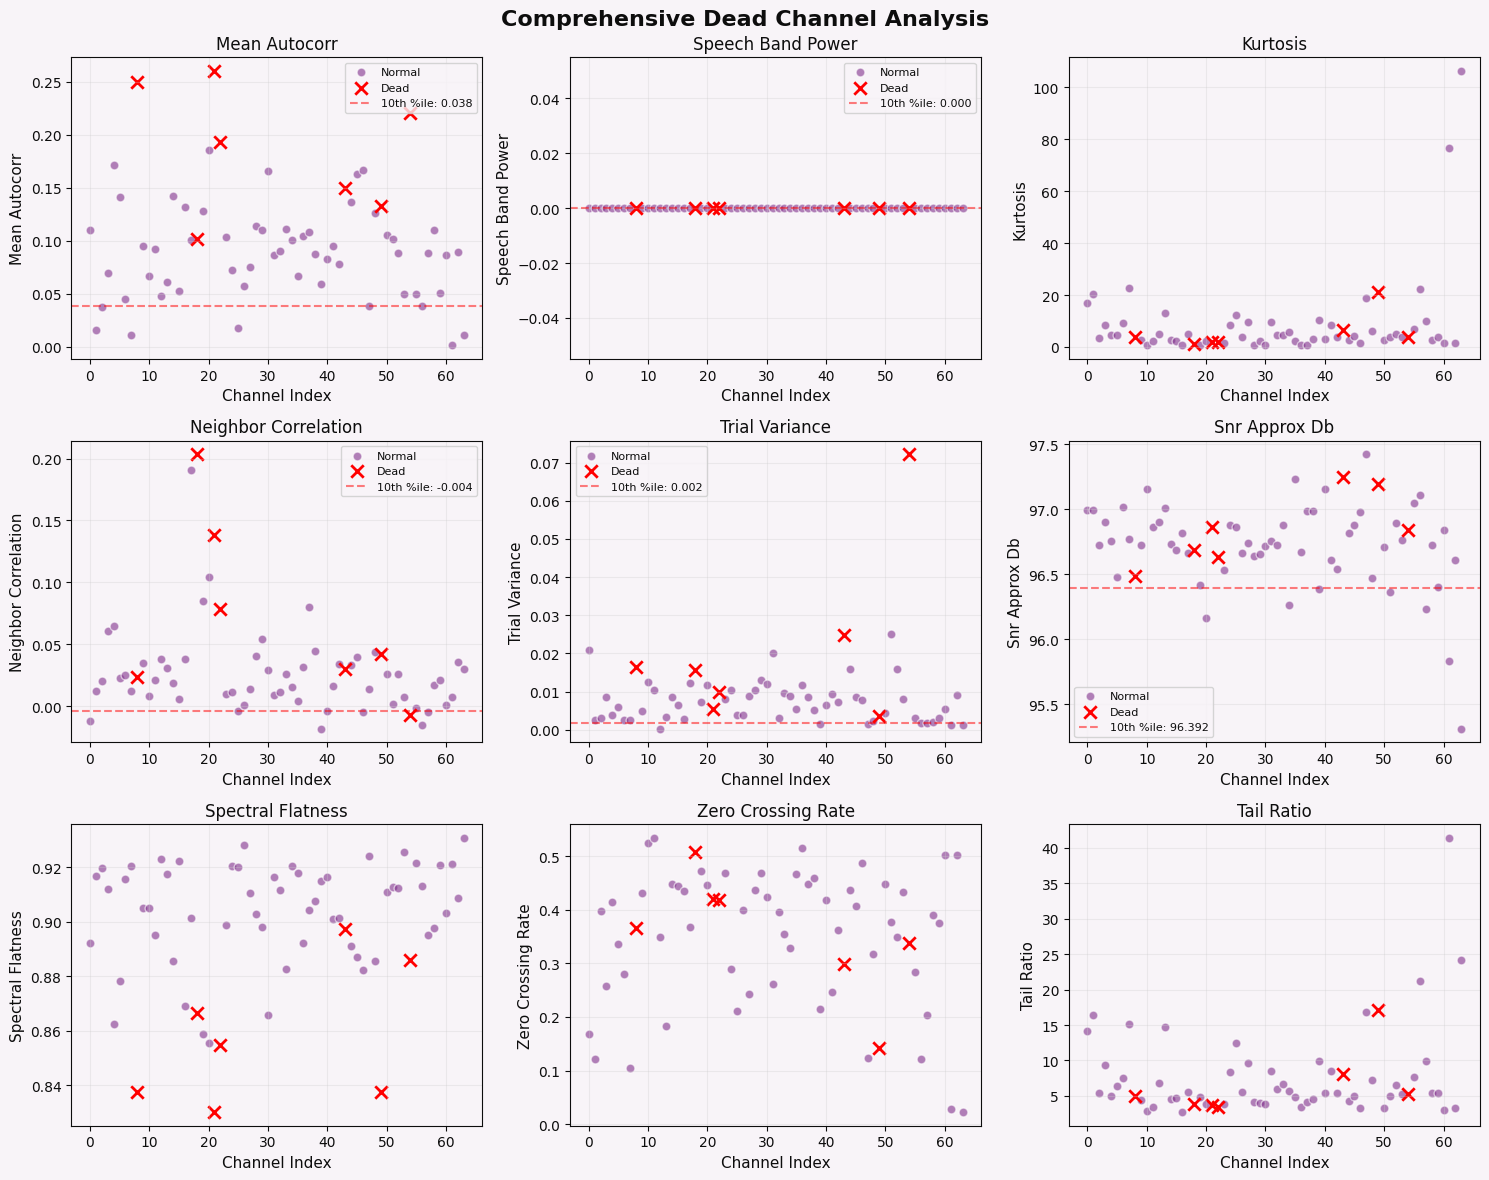

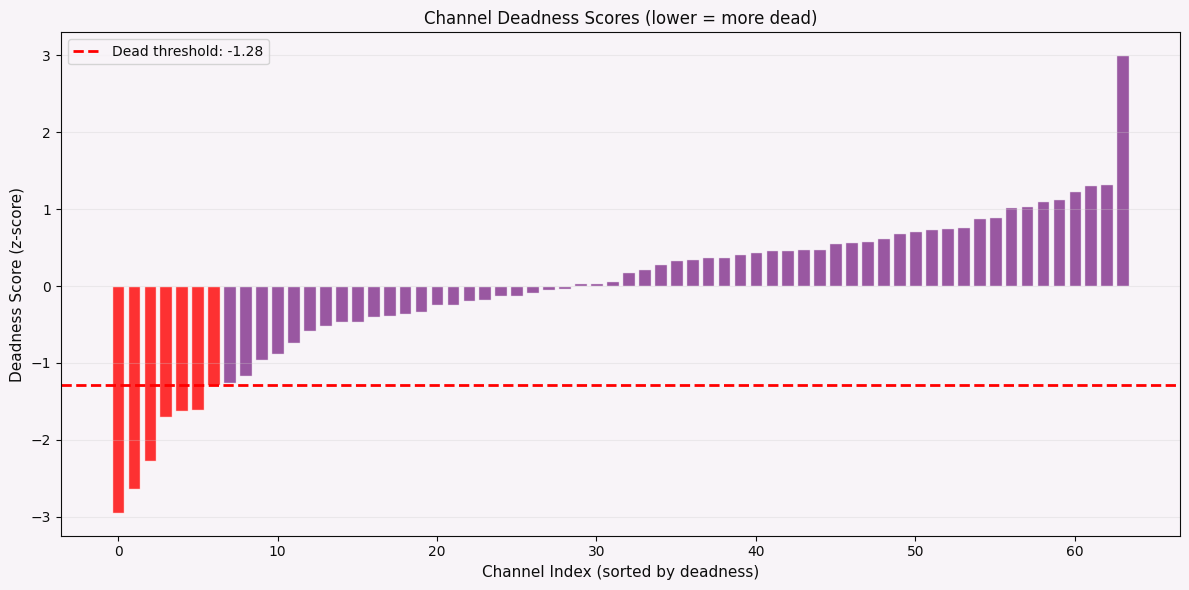


CHANNEL DEADNESS SUMMARY
              Metric All Mean Dead Mean Live Mean Dead/Live Ratio
       Mean Autocorr   0.0985    0.1870    0.0877            2.13
   Speech Band Power   0.0000    0.0000    0.0000            0.00
            Kurtosis   8.5248    5.7350    8.8674            0.65
Neighbor Correlation   0.0308    0.0726    0.0257            2.83
      Trial Variance   0.0088    0.0211    0.0073            2.89


In [24]:
# ============================================================================
# COMPREHENSIVE DEAD CHANNEL DETECTION
# ============================================================================

print("\n" + "="*60)
print("COMPREHENSIVE DEAD CHANNEL DETECTION")
print("="*60)

import numpy as np
from scipy import signal, stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

def compute_dead_channel_metrics(data, suspect_channels=None, sampling_rate=100):
    """
    Compute comprehensive dead channel metrics for suspect channels
    
    Parameters:
    -----------
    data : list
        Your data structure: data[session][split]
    suspect_channels : list or None
        Channels to analyze. If None, analyze all channels
    sampling_rate : int
        Neural data sampling rate in Hz
    
    Returns:
    --------
    metrics_df : pandas DataFrame
        Comprehensive metrics for each channel
    """
    
    # Find a valid session with data
    valid_session = None
    valid_split = None
    
    for s_idx in range(min(5, len(data))):
        if len(data[s_idx]) > 1:  # Has train split
            if ('neural_features' in data[s_idx][1] and 
                data[s_idx][1]['neural_features'] is not None and 
                len(data[s_idx][1]['neural_features']) > 0):
                valid_session = s_idx
                valid_split = 1  # train
                break
    
    if valid_session is None:
        print("✗ No valid data found")
        return None
    
    print(f"✓ Using session {valid_session}, split {valid_split} for analysis")
    
    # Get sample data to determine channel count
    sample_data = data[valid_session][valid_split]
    n_trials = min(10, len(sample_data['neural_features']))
    n_channels = sample_data['neural_features'][0].shape[1]
    
    # If no suspect channels specified, check all
    if suspect_channels is None:
        suspect_channels = list(range(n_channels))
    
    print(f"✓ Analyzing {len(suspect_channels)} channels from {n_trials} trials")
    
    # Initialize metrics storage
    channel_metrics = []
    
    for ch_idx in suspect_channels:
        # Collect data for this channel across trials
        channel_signals = []
        
        for trial_idx in range(n_trials):
            try:
                neural_data = sample_data['neural_features'][trial_idx]
                if ch_idx < neural_data.shape[1]:
                    signal_ch = neural_data[:, ch_idx]
                    channel_signals.append(signal_ch)
            except:
                continue
        
        if len(channel_signals) == 0:
            print(f"  Channel {ch_idx}: No data available")
            continue
        
        # Align signals to same length (take minimum length)
        min_length = min([len(s) for s in channel_signals])
        aligned_signals = np.array([s[:min_length] for s in channel_signals])
        
        # 1. MEAN AUTOCORRELATION (lags 1-5)
        autocorr_values = []
        for sig in aligned_signals:
            # Compute autocorrelation for lags 1-5
            autocorr = np.correlate(sig - np.mean(sig), sig - np.mean(sig), mode='full')
            autocorr = autocorr[len(autocorr)//2:]  # Keep positive lags
            autocorr = autocorr / autocorr[0]  # Normalize
            # Average autocorrelation at lags 1-5
            autocorr_values.append(np.mean(autocorr[1:6]))
        mean_autocorr = np.mean(autocorr_values) if autocorr_values else 0
        
        # 2. SPECTRAL POWER IN SPEECH BANDS (70-150 Hz)
        speech_band_powers = []
        for sig in aligned_signals:
            if len(sig) > 50:
                f, Pxx = signal.welch(sig, fs=sampling_rate, nperseg=min(128, len(sig)))
                speech_mask = (f >= 70) & (f <= 150)
                if np.any(speech_mask):
                    band_power = np.sum(Pxx[speech_mask])
                    total_power = np.sum(Pxx)
                    speech_band_powers.append(band_power / (total_power + 1e-10))
        
        mean_speech_power = np.mean(speech_band_powers) if speech_band_powers else 0
        
        # 3. KURTOSIS AND TAIL PERCENTILES
        all_kurtosis = []
        tail_percentiles = []  # 99th percentile / 50th percentile ratio
        
        for sig in aligned_signals:
            if len(sig) > 10:
                # Kurtosis
                all_kurtosis.append(stats.kurtosis(sig))
                
                # Tail percentile ratio (99th / 50th)
                p99 = np.percentile(np.abs(sig), 99)
                p50 = np.percentile(np.abs(sig), 50)
                tail_percentiles.append(p99 / (p50 + 1e-10))
        
        mean_kurtosis = np.mean(all_kurtosis) if all_kurtosis else 0
        mean_tail_ratio = np.mean(tail_percentiles) if tail_percentiles else 0
        
        # 4. CORRELATION WITH NEIGHBORING CHANNELS
        neighbor_correlations = []
        
        # Define neighbor indices (avoid out of bounds)
        neighbor_indices = []
        if ch_idx > 0:
            neighbor_indices.append(ch_idx - 1)
        if ch_idx < n_channels - 1:
            neighbor_indices.append(ch_idx + 1)
        
        for neighbor_ch in neighbor_indices:
            neighbor_signals = []
            for trial_idx in range(n_trials):
                try:
                    neural_data = sample_data['neural_features'][trial_idx]
                    if neighbor_ch < neural_data.shape[1]:
                        signal_neighbor = neural_data[:, neighbor_ch]
                        neighbor_signals.append(signal_neighbor[:min_length])
                except:
                    continue
            
            if neighbor_signals:
                # Compute correlation between this channel and neighbor across trials
                trial_corrs = []
                for trial_sig, neighbor_sig in zip(aligned_signals, neighbor_signals):
                    if len(trial_sig) == len(neighbor_sig):
                        corr, _ = pearsonr(trial_sig, neighbor_sig)
                        trial_corrs.append(corr)
                
                if trial_corrs:
                    neighbor_correlations.append(np.mean(trial_corrs))
        
        mean_neighbor_corr = np.mean(neighbor_correlations) if neighbor_correlations else 0
        
        # 5. VARIANCE ACROSS TRIALS (not within)
        # Compute mean signal across time for each trial
        trial_means = [np.mean(sig) for sig in aligned_signals]
        trial_var_across = np.var(trial_means) if len(trial_means) > 1 else 0
        
        # 6. ADDITIONAL METRICS
        
        # 6a. Signal-to-Noise Ratio (SNR) approximation
        # For dead channels, signal ≈ noise
        signal_power = np.mean([np.var(sig) for sig in aligned_signals])
        # Estimate noise as high-frequency power
        noise_powers = []
        for sig in aligned_signals:
            if len(sig) > 50:
                f, Pxx = signal.welch(sig, fs=sampling_rate, nperseg=min(128, len(sig)))
                high_freq_mask = f > 100  # High frequency as noise estimate
                if np.any(high_freq_mask):
                    noise_powers.append(np.mean(Pxx[high_freq_mask]))
        
        mean_noise_power = np.mean(noise_powers) if noise_powers else 1e-10
        snr_approx = 10 * np.log10(signal_power / (mean_noise_power + 1e-10))
        
        # 6b. Flatness of spectrum (dead channels have flat spectrum)
        spectral_flatness = []
        for sig in aligned_signals:
            if len(sig) > 50:
                f, Pxx = signal.welch(sig, fs=sampling_rate, nperseg=min(128, len(sig)))
                # Spectral flatness = geometric mean / arithmetic mean
                Pxx_pos = Pxx[Pxx > 0]
                if len(Pxx_pos) > 0:
                    gm = np.exp(np.mean(np.log(Pxx_pos)))
                    am = np.mean(Pxx_pos)
                    spectral_flatness.append(gm / (am + 1e-10))
        
        mean_spectral_flatness = np.mean(spectral_flatness) if spectral_flatness else 0
        
        # 6c. Zero-crossing rate (dead channels may have abnormal rates)
        zc_rates = []
        for sig in aligned_signals:
            zero_crossings = np.where(np.diff(np.sign(sig)))[0]
            zc_rate = len(zero_crossings) / len(sig) if len(sig) > 0 else 0
            zc_rates.append(zc_rate)
        
        mean_zc_rate = np.mean(zc_rates) if zc_rates else 0
        
        # Store metrics for this channel
        channel_metrics.append({
            'channel': ch_idx,
            'mean_autocorr': mean_autocorr,
            'speech_band_power': mean_speech_power,
            'kurtosis': mean_kurtosis,
            'tail_ratio': mean_tail_ratio,
            'neighbor_correlation': mean_neighbor_corr,
            'trial_variance': trial_var_across,
            'snr_approx_db': snr_approx,
            'spectral_flatness': mean_spectral_flatness,
            'zero_crossing_rate': mean_zc_rate,
            'n_trials_analyzed': len(aligned_signals)
        })
        
        # Print progress
        if (ch_idx + 1) % 10 == 0:
            print(f"  Processed {ch_idx + 1}/{len(suspect_channels)} channels")
    
    # Create DataFrame
    metrics_df = pd.DataFrame(channel_metrics)
    
    return metrics_df

def identify_dead_channels(metrics_df, threshold_percentile=10):
    """
    Identify dead channels based on comprehensive metrics
    
    Parameters:
    -----------
    metrics_df : pandas DataFrame
        Channel metrics from compute_dead_channel_metrics
    threshold_percentile : int
        Percentile threshold for considering a channel dead (lower = stricter)
    
    Returns:
    --------
    dead_channels : list
        Indices of identified dead channels
    scores : numpy array
        Deadness scores for each channel
    """
    
    if metrics_df is None or len(metrics_df) == 0:
        return [], []
    
    # Weighted scoring system (lower score = more dead)
    weights = {
        'mean_autocorr': -1.0,      # Dead channels have low autocorrelation
        'speech_band_power': -1.0,  # Dead channels have low speech band power
        'kurtosis': 1.0,            # Dead channels have low kurtosis (flat distribution)
        'tail_ratio': -1.0,         # Dead channels have low tail ratio
        'neighbor_correlation': -1.0, # Dead channels have low correlation with neighbors
        'trial_variance': -1.0,     # Dead channels have low variance across trials
        'snr_approx_db': -1.0,      # Dead channels have low SNR
        'spectral_flatness': 1.0,   # Dead channels have high spectral flatness
        'zero_crossing_rate': 1.0,  # Dead channels may have abnormal zero-crossing
    }
    
    # Normalize each metric (z-score)
    normalized_scores = {}
    for metric in weights.keys():
        if metric in metrics_df.columns:
            values = metrics_df[metric].values
            if np.std(values) > 0:
                normalized_scores[metric] = (values - np.mean(values)) / np.std(values)
            else:
                normalized_scores[metric] = np.zeros_like(values)
    
    # Calculate weighted deadness score
    deadness_scores = np.zeros(len(metrics_df))
    for metric, weight in weights.items():
        if metric in normalized_scores:
            deadness_scores += weight * normalized_scores[metric]
    
    # Normalize final score
    if np.std(deadness_scores) > 0:
        deadness_scores = (deadness_scores - np.mean(deadness_scores)) / np.std(deadness_scores)
    
    # Lower scores are more dead-like
    threshold = np.percentile(deadness_scores, threshold_percentile)
    dead_mask = deadness_scores <= threshold
    
    dead_channels = metrics_df['channel'][dead_mask].tolist()
    
    return dead_channels, deadness_scores

def visualize_dead_channel_analysis(metrics_df, dead_channels, deadness_scores):
    """
    Visualize dead channel analysis results
    """
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle('Comprehensive Dead Channel Analysis', fontsize=16, fontweight='bold', color=CUSTOM_COLORS['dark'])
    
    # Key metrics to visualize
    key_metrics = ['mean_autocorr', 'speech_band_power', 'kurtosis', 
                   'neighbor_correlation', 'trial_variance', 'snr_approx_db',
                   'spectral_flatness', 'zero_crossing_rate', 'tail_ratio']
    
    channels = metrics_df['channel'].values
    is_dead = np.array([ch in dead_channels for ch in channels])
    
    for idx, metric in enumerate(key_metrics):
        if metric in metrics_df.columns:
            ax = axes[idx // 3, idx % 3]
            
            values = metrics_df[metric].values
            
            # Plot normal channels
            ax.scatter(channels[~is_dead], values[~is_dead], 
                      alpha=0.6, s=40, color=CUSTOM_COLORS['primary'], 
                      label='Normal', edgecolor='white')
            
            # Plot dead channels
            if np.any(is_dead):
                ax.scatter(channels[is_dead], values[is_dead], 
                          alpha=1.0, s=80, color='red', marker='x',
                          label='Dead', linewidth=2)
            
            ax.set_xlabel('Channel Index')
            ax.set_ylabel(metric.replace('_', ' ').title())
            ax.set_title(f'{metric.replace("_", " ").title()}')
            ax.grid(True, alpha=0.3)
            
            # Add threshold line for metrics where lower is worse
            if metric in ['mean_autocorr', 'speech_band_power', 'neighbor_correlation', 
                         'trial_variance', 'snr_approx_db']:
                threshold = np.percentile(values, 10)
                ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.5, 
                          label=f'10th %ile: {threshold:.3f}')
                ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig('./results/dead_channel_comprehensive.png', dpi=300, 
                bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
    plt.show()
    
    # Plot deadness scores
    fig2, ax2 = plt.subplots(1, 1, figsize=(12, 6))
    
    # Sort channels by deadness score
    sort_idx = np.argsort(deadness_scores)
    sorted_channels = channels[sort_idx]
    sorted_scores = deadness_scores[sort_idx]
    sorted_dead = is_dead[sort_idx]
    
    # Plot all channels
    bars = ax2.bar(range(len(sorted_channels)), sorted_scores, 
                  color=np.where(sorted_dead, 'red', CUSTOM_COLORS['primary']),
                  alpha=0.8, edgecolor='white')
    
    ax2.set_xlabel('Channel Index (sorted by deadness)')
    ax2.set_ylabel('Deadness Score (z-score)')
    ax2.set_title('Channel Deadness Scores (lower = more dead)')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add threshold line
    threshold = np.percentile(deadness_scores, 10)
    ax2.axhline(y=threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Dead threshold: {threshold:.2f}')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('./results/deadness_scores.png', dpi=300, 
                bbox_inches='tight', facecolor=CUSTOM_COLORS['background'])
    plt.show()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

# Get suspect channels from previous analysis (or use all)
print("Running comprehensive dead channel analysis...")

# If you have previously identified suspect channels, use them:
# suspect_channels = [0, 5, 10, 15]  # Example suspect channels

# Otherwise, analyze all channels up to a reasonable limit
n_channels_sample = 64  # Analyze first 64 channels or adjust based on your data
suspect_channels = list(range(min(n_channels_sample, 
                                 data[1][1]['neural_features'][0].shape[1])))

# Compute comprehensive metrics
metrics_df = compute_dead_channel_metrics(data, suspect_channels)

if metrics_df is not None and len(metrics_df) > 0:
    # Identify dead channels
    dead_channels, deadness_scores = identify_dead_channels(metrics_df, threshold_percentile=10)
    
    # Print results
    print("\n" + "="*60)
    print("COMPREHENSIVE DEAD CHANNEL DETECTION RESULTS")
    print("="*60)
    
    print(f"\nAnalyzed {len(metrics_df)} channels")
    print(f"Identified {len(dead_channels)} dead channels")
    
    if dead_channels:
        print(f"\nDead channel indices: {dead_channels}")
        
        # Show metrics for dead channels
        print(f"\nMetrics for dead channels:")
        print("-" * 80)
        
        dead_metrics = metrics_df[metrics_df['channel'].isin(dead_channels)]
        
        for _, row in dead_metrics.iterrows():
            print(f"\nChannel {int(row['channel'])}:")
            print(f"  Autocorrelation (lags 1-5): {row['mean_autocorr']:.4f} (low = dead)")
            print(f"  Speech band power: {row['speech_band_power']:.4f} (low = dead)")
            print(f"  Kurtosis: {row['kurtosis']:.2f} (low = dead)")
            print(f"  Tail ratio (99th/50th): {row['tail_ratio']:.2f} (low = dead)")
            print(f"  Neighbor correlation: {row['neighbor_correlation']:.4f} (low = dead)")
            print(f"  Trial variance: {row['trial_variance']:.6f} (low = dead)")
            print(f"  SNR (approx): {row['snr_approx_db']:.1f} dB (low = dead)")
            print(f"  Spectral flatness: {row['spectral_flatness']:.3f} (high = dead)")
            print(f"  Zero-crossing rate: {row['zero_crossing_rate']:.3f}")
    
    # Visualize results
    visualize_dead_channel_analysis(metrics_df, dead_channels, deadness_scores)
    
    # Create summary table
    print("\n" + "="*60)
    print("CHANNEL DEADNESS SUMMARY")
    print("="*60)
    
    summary_stats = []
    for metric in ['mean_autocorr', 'speech_band_power', 'kurtosis', 
                   'neighbor_correlation', 'trial_variance']:
        if metric in metrics_df.columns:
            all_values = metrics_df[metric].values
            dead_values = metrics_df[metrics_df['channel'].isin(dead_channels)][metric].values if dead_channels else []
            live_values = metrics_df[~metrics_df['channel'].isin(dead_channels)][metric].values if dead_channels else all_values
            
            if len(dead_values) > 0 and len(live_values) > 0:
                summary_stats.append({
                    'Metric': metric.replace('_', ' ').title(),
                    'All Mean': f"{np.mean(all_values):.4f}",
                    'Dead Mean': f"{np.mean(dead_values):.4f}",
                    'Live Mean': f"{np.mean(live_values):.4f}",
                    'Dead/Live Ratio': f"{np.mean(dead_values)/(np.mean(live_values)+1e-10):.2f}"
                })
    
    summary_df = pd.DataFrame(summary_stats)
    print(summary_df.to_string(index=False))
    
else:
    print("✗ Could not compute channel metrics")